In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/raw/application_train.csv")

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import create_features

df = create_features(df)

In [4]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [6]:
print("Treino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

Treino:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Teste:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

In [8]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (184506, 127) (184506,)
Validation: (61502, 127) (61502,)
Test: (61503, 127) (61503,)


In [9]:
print("Default Train:", y_train.mean())
print("Default Validation:", y_val.mean())
print("Default Test:", y_test.mean())

Default Train: 0.08072908198107379
Default Validation: 0.08072908198107379
Default Test: 0.08072776937710356


In [10]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))

Numéricas: 111
Categóricas: 16


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [12]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [13]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [14]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [17]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
y_val_proba = model.predict_proba(X_val)[:, 1]

In [19]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_val_proba)

print("Validation ROC-AUC:", roc_auc)

Validation ROC-AUC: 0.7452227712600796


In [66]:
import pandas as pd
import numpy as np
import time

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ============================================================
# 1. IDENTIFICAR FEATURES NUMÉRICAS E CATEGÓRICAS
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Features numéricas:", len(numeric_features))
print("Features categóricas:", len(categorical_features))


# ============================================================
# 2. PIPELINE NUMÉRICO
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# ============================================================
# 3. PIPELINE CATEGÓRICO
# ============================================================

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# ============================================================
# 4. JUNTAR PREPROCESSAMENTO
# ============================================================

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])


# ============================================================
# 5. FIT DO PREPROCESSING SOMENTE NO TRAIN
# ============================================================

print("Processando X_train...")

X_train_processed = preprocessor.fit_transform(X_train)

print("Processando X_val...")

X_val_processed = preprocessor.transform(X_val)

print("Shape após preprocessing:")
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)


# ============================================================
# 6. CALCULAR DESBALANCEAMENTO
# ============================================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(
    "scale_pos_weight:",
    round(scale_pos_weight, 2)
)


# ============================================================
# 7. DEFINIR MODELOS
# ============================================================

models = {

    # --------------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------------

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),


    # --------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),



    # --------------------------------------------------------
    # HISTOGRAM GRADIENT BOOSTING
    # --------------------------------------------------------

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42
    ),


    # --------------------------------------------------------
    # XGBOOST
    # --------------------------------------------------------

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,

        subsample=0.8,
        colsample_bytree=0.8,

        scale_pos_weight=scale_pos_weight,

        eval_metric="logloss",

        random_state=42,
        n_jobs=-1
    ),


    # --------------------------------------------------------
    # LIGHTGBM
    # --------------------------------------------------------

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,

        num_leaves=31,

        class_weight="balanced",

        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),


    # --------------------------------------------------------
    # REDE NEURAL
    # --------------------------------------------------------

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64),

        activation="relu",

        solver="adam",

        learning_rate_init=0.001,

        batch_size=512,

        max_iter=100,

        early_stopping=True,

        validation_fraction=0.1,

        random_state=42
    )
}


# ============================================================
# 8. TREINAR TODOS OS MODELOS
# ============================================================

results = {}

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(f"Treinando: {name}")
    print("=" * 60)

    start_time = time.time()

    model.fit(
        X_train_processed,
        y_train
    )

    y_val_proba = model.predict_proba(
        X_val_processed
    )[:, 1]

    roc_auc = roc_auc_score(
        y_val,
        y_val_proba
    )

    elapsed_time = time.time() - start_time

    results[name] = {
        "ROC_AUC": roc_auc,
        "Training_Time_Seconds": elapsed_time
    }

    trained_models[name] = model

    print(
        f"ROC-AUC: {roc_auc:.4f}"
    )

    print(
        f"Tempo: {elapsed_time:.1f} segundos"
    )


# ============================================================
# 9. CRIAR TABELA DE RESULTADOS
# ============================================================

results_df = pd.DataFrame(
    results
).T

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

results_df

Features numéricas: 111
Features categóricas: 16
Processando X_train...
Processando X_val...
Shape após preprocessing:
Train: (184506, 257)
Validation: (61502, 257)
scale_pos_weight: 11.39

Treinando: Logistic Regression
ROC-AUC: 0.7452
Tempo: 13.2 segundos

Treinando: Random Forest



KeyboardInterrupt



## Baseline Model Results

Seven classification algorithms were evaluated using the same
train/validation split and preprocessing pipeline.

Best validation performance:

- XGBoost: ROC-AUC = 0.7546
- HistGradientBoosting: ROC-AUC = 0.7539
- LightGBM: ROC-AUC = 0.7526
- Logistic Regression: ROC-AUC = 0.7452
- Neural Network: ROC-AUC = 0.7384
- Random Forest: ROC-AUC = 0.7332
- Extra Trees: ROC-AUC = 0.7225

XGBoost was selected as the leading baseline model.

The next stage will incorporate historical credit information
from the relational Home Credit datasets through feature engineering.

In [67]:
bureau = pd.read_csv("../data/raw/bureau.csv")

In [68]:
bureau.shape

(1716428, 17)

In [69]:
bureau["SK_ID_CURR"].nunique()

305811

In [70]:
bureau["SK_ID_CURR"].duplicated().sum()

np.int64(1410617)

In [71]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg(

    # Quantidade de créditos encontrados no bureau
    BUREAU_CREDIT_COUNT=(
        "SK_ID_BUREAU",
        "count"
    ),

    # Valor total de crédito
    BUREAU_CREDIT_SUM_TOTAL=(
        "AMT_CREDIT_SUM",
        "sum"
    ),

    # Valor médio dos créditos
    BUREAU_CREDIT_SUM_MEAN=(
        "AMT_CREDIT_SUM",
        "mean"
    ),

    # Maior crédito
    BUREAU_CREDIT_SUM_MAX=(
        "AMT_CREDIT_SUM",
        "max"
    ),

    # Dívida total atual
    BUREAU_DEBT_TOTAL=(
        "AMT_CREDIT_SUM_DEBT",
        "sum"
    ),

    # Dívida média
    BUREAU_DEBT_MEAN=(
        "AMT_CREDIT_SUM_DEBT",
        "mean"
    ),

    # Limite/saldo vencido total
    BUREAU_OVERDUE_TOTAL=(
        "AMT_CREDIT_SUM_OVERDUE",
        "sum"
    ),

    # Maior valor vencido
    BUREAU_OVERDUE_MAX=(
        "AMT_CREDIT_SUM_OVERDUE",
        "max"
    ),

    # Maior quantidade de dias em atraso
    BUREAU_MAX_DAYS_OVERDUE=(
        "CREDIT_DAY_OVERDUE",
        "max"
    ),

    # Quantidade média de dias em atraso
    BUREAU_MEAN_DAYS_OVERDUE=(
        "CREDIT_DAY_OVERDUE",
        "mean"
    ),

    # Crédito mais recente
    BUREAU_DAYS_CREDIT_MAX=(
        "DAYS_CREDIT",
        "max"
    ),

    # Antiguidade média dos créditos
    BUREAU_DAYS_CREDIT_MEAN=(
        "DAYS_CREDIT",
        "mean"
    )

).reset_index()

In [72]:
bureau_agg.shape

(305811, 13)

In [73]:
bureau["CREDIT_ACTIVE"].value_counts(dropna=False)

CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

In [74]:
credit_status = (
    bureau
    .pivot_table(
        index="SK_ID_CURR",
        columns="CREDIT_ACTIVE",
        values="SK_ID_BUREAU",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

In [75]:
credit_status = credit_status.rename(columns={
    "Active": "BUREAU_ACTIVE_COUNT",
    "Closed": "BUREAU_CLOSED_COUNT",
    "Sold": "BUREAU_SOLD_COUNT",
    "Bad debt": "BUREAU_BAD_DEBT_COUNT"
})

In [76]:
credit_status.head()

CREDIT_ACTIVE,SK_ID_CURR,BUREAU_ACTIVE_COUNT,BUREAU_BAD_DEBT_COUNT,BUREAU_CLOSED_COUNT,BUREAU_SOLD_COUNT
0,100001,3,0,4,0
1,100002,2,0,6,0
2,100003,1,0,3,0
3,100004,0,0,2,0
4,100005,2,0,1,0


In [77]:
credit_status.shape

(305811, 5)

In [78]:
bureau_features = bureau_agg.merge(
    credit_status,
    on="SK_ID_CURR",
    how="left"
)

bureau_features.shape

(305811, 17)

In [79]:
bureau_features["BUREAU_ACTIVE_RATIO"] = (
    bureau_features["BUREAU_ACTIVE_COUNT"] /
    bureau_features["BUREAU_CREDIT_COUNT"]
)

bureau_features["BUREAU_CLOSED_RATIO"] = (
    bureau_features["BUREAU_CLOSED_COUNT"] /
    bureau_features["BUREAU_CREDIT_COUNT"]
)

In [80]:
bureau_features["BUREAU_DEBT_CREDIT_RATIO"] = (
    bureau_features["BUREAU_DEBT_TOTAL"] /
    bureau_features["BUREAU_CREDIT_SUM_TOTAL"]
)

In [81]:
bureau_features = bureau_features.replace(
    [np.inf, -np.inf],
    np.nan
)

In [82]:
bureau_features[
    [
        "BUREAU_CREDIT_COUNT",
        "BUREAU_ACTIVE_COUNT",
        "BUREAU_CLOSED_COUNT",
        "BUREAU_ACTIVE_RATIO",
        "BUREAU_DEBT_TOTAL",
        "BUREAU_CREDIT_SUM_TOTAL",
        "BUREAU_DEBT_CREDIT_RATIO",
        "BUREAU_MAX_DAYS_OVERDUE"
    ]
].describe()

,BUREAU_CREDIT_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_CLOSED_COUNT,BUREAU_ACTIVE_RATIO,BUREAU_DEBT_TOTAL,BUREAU_CREDIT_SUM_TOTAL,BUREAU_DEBT_CREDIT_RATIO,BUREAU_MAX_DAYS_OVERDUE
count,305811.000000,305811.000000,305811.000000,305811.000000,3.058110e+05,3.058110e+05,304535.000000,305811.000000
mean,5.612709,2.062081,3.529216,0.410223,6.539142e+05,1.992466e+06,0.282230,4.436629
std,4.430354,1.791724,3.430504,0.307228,1.640691e+06,4.165820e+06,0.431856,85.573591
min,1.000000,0.000000,0.000000,0.000000,-6.981558e+06,0.000000e+00,-175.289231,0.000000
25%,2.000000,1.000000,1.000000,0.200000,0.000000e+00,3.469676e+05,0.000000,0.000000
50%,4.000000,2.000000,3.000000,0.375000,1.733670e+05,9.788207e+05,0.210886,0.000000
75%,8.000000,3.000000,5.000000,0.600000,6.765412e+05,2.345121e+06,0.481842,0.000000
max,116.000000,32.000000,108.000000,1.000000,3.344983e+08,1.017958e+09,7.789100,2792.000000


In [83]:
df_bureau = df.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

print("Antes:", df.shape)
print("Depois:", df_bureau.shape)

Antes: (307511, 128)
Depois: (307511, 147)


In [84]:
assert len(df_bureau) == len(df)

print("Merge realizado sem duplicar clientes.")

Merge realizado sem duplicar clientes.


In [85]:
X_bureau = df_bureau.drop(columns=["TARGET"])
y_bureau = df_bureau["TARGET"]

In [86]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bureau,
    y_bureau,
    test_size=0.20,
    stratify=y_bureau,
    random_state=42
)

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_train_b,
    y_train_b,
    test_size=0.25,
    stratify=y_train_b,
    random_state=42
)

print(X_train_b.shape)
print(X_val_b.shape)
print(X_test_b.shape)

(184506, 146)
(61502, 146)
(61503, 146)


In [87]:
numeric_features_b = X_train_b.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features_b = X_train_b.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

In [88]:
numeric_pipeline_b = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_b = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor_b = ColumnTransformer([
    ("num", numeric_pipeline_b, numeric_features_b),
    ("cat", categorical_pipeline_b, categorical_features_b)
])

In [89]:
X_train_b_processed = preprocessor_b.fit_transform(X_train_b)
X_val_b_processed = preprocessor_b.transform(X_val_b)

print(X_train_b_processed.shape)
print(X_val_b_processed.shape)

(184506, 276)
(61502, 276)


In [90]:
negative = (y_train_b == 0).sum()
positive = (y_train_b == 1).sum()

scale_pos_weight_b = negative / positive

In [91]:
xgb_bureau = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_b,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_bureau.fit(
    X_train_b_processed,
    y_train_b
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [92]:
y_val_b_proba = xgb_bureau.predict_proba(
    X_val_b_processed
)[:, 1]

auc_bureau = roc_auc_score(
    y_val_b,
    y_val_b_proba
)

print(f"Baseline XGBoost:     0.7546")
print(f"XGBoost + Bureau:     {auc_bureau:.4f}")
print(f"Melhoria absoluta:    {auc_bureau - 0.754609:.4f}")

Baseline XGBoost:     0.7546
XGBoost + Bureau:     0.7605
Melhoria absoluta:    0.0059


In [93]:
previous = pd.read_csv("../data/raw/previous_application.csv")

print("Shape:", previous.shape)
print("Clientes únicos:", previous["SK_ID_CURR"].nunique())

previous.head()

Shape: (1670214, 37)
Clientes únicos: 338857


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
cols = [
    "NAME_CONTRACT_STATUS",
    "AMT_APPLICATION",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_DOWN_PAYMENT",
    "DAYS_DECISION"
]

previous[cols].describe(include="all")

,NAME_CONTRACT_STATUS,AMT_APPLICATION,AMT_CREDIT,AMT_ANNUITY,AMT_DOWN_PAYMENT,DAYS_DECISION
count,1670214,1.670214e+06,1.670213e+06,1.297979e+06,7.743700e+05,1.670214e+06
unique,4,NaN,NaN,NaN,NaN,NaN
top,Approved,NaN,NaN,NaN,NaN,NaN
freq,1036781,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.752339e+05,1.961140e+05,1.595512e+04,6.697402e+03,-8.806797e+02
std,NaN,2.927798e+05,3.185746e+05,1.478214e+04,2.092150e+04,7.790997e+02
min,NaN,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e-01,-2.922000e+03
25%,NaN,1.872000e+04,2.416050e+04,6.321780e+03,0.000000e+00,-1.300000e+03
50%,NaN,7.104600e+04,8.054100e+04,1.125000e+04,1.638000e+03,-5.810000e+02
75%,NaN,1.803600e+05,2.164185e+05,2.065842e+04,7.740000e+03,-2.800000e+02


In [95]:
previous["NAME_CONTRACT_STATUS"].value_counts(dropna=False)

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [96]:
print("Shape:", previous.shape)
print("Clientes únicos:", previous["SK_ID_CURR"].nunique())

print("\nStatus:")
print(previous["NAME_CONTRACT_STATUS"].value_counts(dropna=False))

Shape: (1670214, 37)
Clientes únicos: 338857

Status:
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [97]:
previous_agg = previous.groupby("SK_ID_CURR").agg(

    # Quantidade de aplicações anteriores
    PREV_APPLICATION_COUNT=(
        "SK_ID_PREV",
        "count"
    ),

    # Valores solicitados
    PREV_APPLICATION_MEAN=(
        "AMT_APPLICATION",
        "mean"
    ),

    PREV_APPLICATION_MAX=(
        "AMT_APPLICATION",
        "max"
    ),

    # Valores efetivamente concedidos
    PREV_CREDIT_MEAN=(
        "AMT_CREDIT",
        "mean"
    ),

    PREV_CREDIT_MAX=(
        "AMT_CREDIT",
        "max"
    ),

    PREV_CREDIT_SUM=(
        "AMT_CREDIT",
        "sum"
    ),

    # Parcelas
    PREV_ANNUITY_MEAN=(
        "AMT_ANNUITY",
        "mean"
    ),

    PREV_ANNUITY_MAX=(
        "AMT_ANNUITY",
        "max"
    ),

    # Entrada
    PREV_DOWN_PAYMENT_MEAN=(
        "AMT_DOWN_PAYMENT",
        "mean"
    ),

    # Quando ocorreu a decisão anterior
    PREV_DAYS_DECISION_MEAN=(
        "DAYS_DECISION",
        "mean"
    ),

    PREV_DAYS_DECISION_MAX=(
        "DAYS_DECISION",
        "max"
    )

).reset_index()

previous_agg.shape

(338857, 12)

In [98]:
previous_status = (
    previous
    .pivot_table(
        index="SK_ID_CURR",
        columns="NAME_CONTRACT_STATUS",
        values="SK_ID_PREV",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

previous_status.head()

NAME_CONTRACT_STATUS,SK_ID_CURR,Approved,Canceled,Refused,Unused offer
0,100001,1,0,0,0
1,100002,1,0,0,0
2,100003,3,0,0,0
3,100004,1,0,0,0
4,100005,1,1,0,0


In [99]:
previous_status.columns.tolist()

['SK_ID_CURR', 'Approved', 'Canceled', 'Refused', 'Unused offer']

In [100]:
previous_status = previous_status.rename(columns={
    "Approved": "PREV_APPROVED_COUNT",
    "Refused": "PREV_REFUSED_COUNT",
    "Canceled": "PREV_CANCELED_COUNT",
    "Unused offer": "PREV_UNUSED_COUNT"
})

In [101]:
previous_features = previous_agg.merge(
    previous_status,
    on="SK_ID_CURR",
    how="left"
)

previous_features.shape

(338857, 16)

In [102]:
previous_features["PREV_APPROVAL_RATIO"] = (
    previous_features["PREV_APPROVED_COUNT"] /
    previous_features["PREV_APPLICATION_COUNT"]
)

previous_features["PREV_REFUSAL_RATIO"] = (
    previous_features["PREV_REFUSED_COUNT"] /
    previous_features["PREV_APPLICATION_COUNT"]
)

In [103]:
previous_features["PREV_CREDIT_APPLICATION_RATIO"] = (
    previous_features["PREV_CREDIT_MEAN"] /
    previous_features["PREV_APPLICATION_MEAN"]
)

In [104]:
previous_features = previous_features.replace(
    [np.inf, -np.inf],
    np.nan
)

In [105]:
df_bureau_previous = df_bureau.merge(
    previous_features,
    on="SK_ID_CURR",
    how="left"
)

print("Antes:", df_bureau.shape)
print("Depois:", df_bureau_previous.shape)

Antes: (307511, 147)
Depois: (307511, 165)


In [106]:
assert len(df_bureau_previous) == len(df_bureau)

print("Merge realizado sem duplicar clientes.")

Merge realizado sem duplicar clientes.


In [107]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


def evaluate_xgboost(dataset, dataset_name):

    # -----------------------------------------
    # 1. Separar X e y
    # -----------------------------------------
    X = dataset.drop(columns=["TARGET"])
    y = dataset["TARGET"]

    # -----------------------------------------
    # 2. Train / Test
    # -----------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # -----------------------------------------
    # 3. Train / Validation
    # -----------------------------------------
    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.25,
        stratify=y_train,
        random_state=42
    )

    # -----------------------------------------
    # 4. Identificar tipos de features
    # -----------------------------------------
    numeric_features = X_train.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_features = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    # -----------------------------------------
    # 5. Preprocessing
    # -----------------------------------------
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    # IMPORTANTE:
    # fit somente no treino
    X_train_processed = preprocessor.fit_transform(X_train)

    # validation apenas recebe transform
    X_val_processed = preprocessor.transform(X_val)

    # -----------------------------------------
    # 6. Peso da classe minoritária
    # -----------------------------------------
    negative = (y_train == 0).sum()
    positive = (y_train == 1).sum()

    scale_pos_weight = negative / positive

    # -----------------------------------------
    # 7. XGBoost
    # -----------------------------------------
    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_processed,
        y_train
    )

    # -----------------------------------------
    # 8. Probabilidades
    # -----------------------------------------
    y_val_proba = model.predict_proba(
        X_val_processed
    )[:, 1]

    # -----------------------------------------
    # 9. ROC-AUC
    # -----------------------------------------
    auc = roc_auc_score(
        y_val,
        y_val_proba
    )

    print(f"{dataset_name}: ROC-AUC = {auc:.4f}")

    return auc

In [108]:
auc_bureau_previous = evaluate_xgboost(
    df_bureau_previous,
    "Application + Bureau + Previous"
)

Application + Bureau + Previous: ROC-AUC = 0.7649


In [109]:
import pandas as pd
import numpy as np


# ============================================================
# 1. CARREGAR INSTALLMENTS
# ============================================================

installments = pd.read_csv(
    "../data/raw/installments_payments.csv"
)

print("Shape:", installments.shape)
print(
    "Clientes únicos:",
    installments["SK_ID_CURR"].nunique()
)


# ============================================================
# 2. FEATURE NO NÍVEL DE CADA PAGAMENTO
# ============================================================

# Dias de atraso
installments["PAYMENT_DELAY_DAYS"] = (
    installments["DAYS_ENTRY_PAYMENT"]
    - installments["DAYS_INSTALMENT"]
)

# Pagamento antecipado/em dia vira 0
installments["PAYMENT_DELAY_DAYS"] = (
    installments["PAYMENT_DELAY_DAYS"]
    .clip(lower=0)
)


# Valor que deixou de ser pago
installments["PAYMENT_SHORTFALL"] = (
    installments["AMT_INSTALMENT"]
    - installments["AMT_PAYMENT"]
)

installments["PAYMENT_SHORTFALL"] = (
    installments["PAYMENT_SHORTFALL"]
    .clip(lower=0)
)


# Indicador: parcela atrasou?
installments["PAYMENT_LATE"] = (
    installments["PAYMENT_DELAY_DAYS"] > 0
).astype(int)


# Indicador: pagamento foi menor que a parcela?
installments["PAYMENT_INCOMPLETE"] = (
    installments["PAYMENT_SHORTFALL"] > 0
).astype(int)


# ============================================================
# 3. AGREGAR POR CLIENTE
# ============================================================

installments_agg = installments.groupby(
    "SK_ID_CURR"
).agg(

    # Quantidade total de registros de pagamento
    INSTALLMENT_PAYMENT_COUNT=(
        "SK_ID_PREV",
        "count"
    ),

    # Atraso médio
    INSTALLMENT_MEAN_DELAY=(
        "PAYMENT_DELAY_DAYS",
        "mean"
    ),

    # Maior atraso
    INSTALLMENT_MAX_DELAY=(
        "PAYMENT_DELAY_DAYS",
        "max"
    ),

    # Soma dos dias de atraso
    INSTALLMENT_TOTAL_DELAY=(
        "PAYMENT_DELAY_DAYS",
        "sum"
    ),

    # Quantidade de pagamentos atrasados
    INSTALLMENT_LATE_COUNT=(
        "PAYMENT_LATE",
        "sum"
    ),

    # Valor total que deixou de ser pago
    INSTALLMENT_SHORTFALL_TOTAL=(
        "PAYMENT_SHORTFALL",
        "sum"
    ),

    # Valor médio não pago
    INSTALLMENT_SHORTFALL_MEAN=(
        "PAYMENT_SHORTFALL",
        "mean"
    ),

    # Maior valor não pago
    INSTALLMENT_SHORTFALL_MAX=(
        "PAYMENT_SHORTFALL",
        "max"
    ),

    # Quantidade de pagamentos incompletos
    INSTALLMENT_INCOMPLETE_COUNT=(
        "PAYMENT_INCOMPLETE",
        "sum"
    ),

    # Valor médio da parcela
    INSTALLMENT_AMOUNT_MEAN=(
        "AMT_INSTALMENT",
        "mean"
    ),

    # Valor médio efetivamente pago
    PAYMENT_AMOUNT_MEAN=(
        "AMT_PAYMENT",
        "mean"
    )

).reset_index()


# ============================================================
# 4. CRIAR RATIOS
# ============================================================

installments_agg["INSTALLMENT_LATE_RATIO"] = (
    installments_agg["INSTALLMENT_LATE_COUNT"]
    / installments_agg["INSTALLMENT_PAYMENT_COUNT"]
)

installments_agg["INSTALLMENT_INCOMPLETE_RATIO"] = (
    installments_agg["INSTALLMENT_INCOMPLETE_COUNT"]
    / installments_agg["INSTALLMENT_PAYMENT_COUNT"]
)

installments_agg["PAYMENT_INSTALLMENT_RATIO"] = (
    installments_agg["PAYMENT_AMOUNT_MEAN"]
    / installments_agg["INSTALLMENT_AMOUNT_MEAN"]
)

installments_agg = installments_agg.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 5. INSPECIONAR RESULTADO
# ============================================================

print("Installments agregada:")
print(installments_agg.shape)

display(
    installments_agg.head()
)


# ============================================================
# 6. MERGE COM O DATASET ATUAL
# ============================================================

df_full = df_bureau_previous.merge(
    installments_agg,
    on="SK_ID_CURR",
    how="left"
)

print("Antes:", df_bureau_previous.shape)
print("Depois:", df_full.shape)


# Garantir que nenhum cliente foi duplicado
assert len(df_full) == len(df_bureau_previous)

print("Merge realizado sem duplicar clientes.")


# ============================================================
# 7. AVALIAR XGBOOST
# ============================================================

auc_full = evaluate_xgboost(
    df_full,
    "Application + Bureau + Previous + Installments"
)

print()
print("Resultados até agora:")
print("Application:                         0.7546")
print("Application + Bureau:                0.7605")
print("Application + Bureau + Previous:     0.7649")
print(
    f"+ Installments:                      {auc_full:.4f}"
)

Shape: (13605401, 8)
Clientes únicos: 339587
Installments agregada:
(339587, 15)


,SK_ID_CURR,INSTALLMENT_PAYMENT_COUNT,INSTALLMENT_MEAN_DELAY,INSTALLMENT_MAX_DELAY,INSTALLMENT_TOTAL_DELAY,INSTALLMENT_LATE_COUNT,INSTALLMENT_SHORTFALL_TOTAL,INSTALLMENT_SHORTFALL_MEAN,INSTALLMENT_SHORTFALL_MAX,INSTALLMENT_INCOMPLETE_COUNT,INSTALLMENT_AMOUNT_MEAN,PAYMENT_AMOUNT_MEAN,INSTALLMENT_LATE_RATIO,INSTALLMENT_INCOMPLETE_RATIO,PAYMENT_INSTALLMENT_RATIO
0,100001,7,1.571429,11.0,11.0,1,0.0,0.0,0.0,0,5885.132143,5885.132143,0.142857,0.0,1.0
1,100002,19,0.000000,0.0,0.0,0,0.0,0.0,0.0,0,11559.247105,11559.247105,0.000000,0.0,1.0
2,100003,25,0.000000,0.0,0.0,0,0.0,0.0,0.0,0,64754.586000,64754.586000,0.000000,0.0,1.0
3,100004,3,0.000000,0.0,0.0,0,0.0,0.0,0.0,0,7096.155000,7096.155000,0.000000,0.0,1.0
4,100005,9,0.111111,1.0,1.0,1,0.0,0.0,0.0,0,6240.205000,6240.205000,0.111111,0.0,1.0


Antes: (307511, 165)
Depois: (307511, 179)
Merge realizado sem duplicar clientes.
Application + Bureau + Previous + Installments: ROC-AUC = 0.7704

Resultados até agora:
Application:                         0.7546
Application + Bureau:                0.7605
Application + Bureau + Previous:     0.7649
+ Installments:                      0.7704


In [110]:
import pandas as pd
import numpy as np


# ============================================================
# 1. CARREGAR CREDIT CARD BALANCE
# ============================================================

credit_card = pd.read_csv(
    "../data/raw/credit_card_balance.csv"
)

print("Shape:", credit_card.shape)
print(
    "Clientes únicos:",
    credit_card["SK_ID_CURR"].nunique()
)


# ============================================================
# 2. FEATURES NO NÍVEL DE CADA REGISTRO MENSAL
# ============================================================

# Utilização do limite do cartão
credit_card["CC_UTILIZATION"] = (
    credit_card["AMT_BALANCE"]
    / credit_card["AMT_CREDIT_LIMIT_ACTUAL"]
)

# Indicador de atraso
credit_card["CC_HAS_DPD"] = (
    credit_card["SK_DPD"] > 0
).astype(int)

# Indicador de atraso mais severo
credit_card["CC_HAS_DPD_DEF"] = (
    credit_card["SK_DPD_DEF"] > 0
).astype(int)


# ============================================================
# 3. AGREGAR POR CLIENTE
# ============================================================

credit_card_agg = credit_card.groupby(
    "SK_ID_CURR"
).agg(

    # Quantidade de observações mensais
    CC_MONTH_COUNT=(
        "MONTHS_BALANCE",
        "count"
    ),

    # Saldo
    CC_BALANCE_MEAN=(
        "AMT_BALANCE",
        "mean"
    ),

    CC_BALANCE_MAX=(
        "AMT_BALANCE",
        "max"
    ),

    # Limite
    CC_LIMIT_MEAN=(
        "AMT_CREDIT_LIMIT_ACTUAL",
        "mean"
    ),

    # Utilização do limite
    CC_UTILIZATION_MEAN=(
        "CC_UTILIZATION",
        "mean"
    ),

    CC_UTILIZATION_MAX=(
        "CC_UTILIZATION",
        "max"
    ),

    # Saques
    CC_DRAWINGS_MEAN=(
        "AMT_DRAWINGS_CURRENT",
        "mean"
    ),

    CC_DRAWINGS_MAX=(
        "AMT_DRAWINGS_CURRENT",
        "max"
    ),

    # Pagamentos
    CC_PAYMENT_MEAN=(
        "AMT_PAYMENT_CURRENT",
        "mean"
    ),

    CC_PAYMENT_TOTAL_MEAN=(
        "AMT_PAYMENT_TOTAL_CURRENT",
        "mean"
    ),

    # Atrasos
    CC_DPD_MEAN=(
        "SK_DPD",
        "mean"
    ),

    CC_DPD_MAX=(
        "SK_DPD",
        "max"
    ),

    CC_DPD_DEF_MEAN=(
        "SK_DPD_DEF",
        "mean"
    ),

    CC_DPD_DEF_MAX=(
        "SK_DPD_DEF",
        "max"
    ),

    # Quantidade de meses com atraso
    CC_DPD_COUNT=(
        "CC_HAS_DPD",
        "sum"
    ),

    CC_DPD_DEF_COUNT=(
        "CC_HAS_DPD_DEF",
        "sum"
    )

).reset_index()


# ============================================================
# 4. RATIOS DE ATRASO
# ============================================================

credit_card_agg["CC_DPD_RATIO"] = (
    credit_card_agg["CC_DPD_COUNT"]
    / credit_card_agg["CC_MONTH_COUNT"]
)

credit_card_agg["CC_DPD_DEF_RATIO"] = (
    credit_card_agg["CC_DPD_DEF_COUNT"]
    / credit_card_agg["CC_MONTH_COUNT"]
)


# ============================================================
# 5. TRATAR INFINITOS
# ============================================================

credit_card_agg = credit_card_agg.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 6. INSPECIONAR
# ============================================================

print(
    "Credit Card agregada:",
    credit_card_agg.shape
)

display(
    credit_card_agg.head()
)


# ============================================================
# 7. MERGE COM DATASET ATUAL
# ============================================================

df_full_cc = df_full.merge(
    credit_card_agg,
    on="SK_ID_CURR",
    how="left"
)

print(
    "Antes:",
    df_full.shape
)

print(
    "Depois:",
    df_full_cc.shape
)

assert len(df_full_cc) == len(df_full)

print(
    "Merge realizado sem duplicar clientes."
)


# ============================================================
# 8. AVALIAR
# ============================================================

auc_full_cc = evaluate_xgboost(
    df_full_cc,
    "Application + Bureau + Previous + Installments + Credit Card"
)


# ============================================================
# 9. COMPARAÇÃO
# ============================================================

print()
print("EVOLUÇÃO DO MODELO")
print("-" * 55)

print("Application:                          0.7546")
print("Application + Bureau:                 0.7605")
print("Application + Bureau + Previous:      0.7649")
print("Application + Bureau + Previous")
print(" + Installments:                      0.7704")

print(
    f" + Credit Card:                       {auc_full_cc:.4f}"
)

Shape: (3840312, 23)
Clientes únicos: 103558
Credit Card agregada: (103558, 19)


,SK_ID_CURR,CC_MONTH_COUNT,CC_BALANCE_MEAN,CC_BALANCE_MAX,CC_LIMIT_MEAN,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_DRAWINGS_MEAN,CC_DRAWINGS_MAX,CC_PAYMENT_MEAN,CC_PAYMENT_TOTAL_MEAN,CC_DPD_MEAN,CC_DPD_MAX,CC_DPD_DEF_MEAN,CC_DPD_DEF_MAX,CC_DPD_COUNT,CC_DPD_DEF_COUNT,CC_DPD_RATIO,CC_DPD_DEF_RATIO
0,100006,6,0.000000,0.00,270000.000000,0.000000,0.00000,0.000000,0.0,NaN,0.000000,0.000000,0,0.000000,0,0,0,0.000000,0.000000
1,100011,74,54482.111149,189000.00,164189.189189,0.302678,1.05000,2432.432432,180000.0,4843.064189,4520.067568,0.000000,0,0.000000,0,0,0,0.000000,0.000000
2,100013,96,18159.919219,161420.22,131718.750000,0.115301,1.02489,5953.125000,157500.0,7168.346250,6817.172344,0.010417,1,0.010417,1,1,1,0.010417,0.010417
3,100021,17,0.000000,0.00,675000.000000,0.000000,0.00000,0.000000,0.0,NaN,0.000000,0.000000,0,0.000000,0,0,0,0.000000,0.000000
4,100023,8,0.000000,0.00,135000.000000,0.000000,0.00000,0.000000,0.0,NaN,0.000000,0.000000,0,0.000000,0,0,0,0.000000,0.000000


Antes: (307511, 179)
Depois: (307511, 197)
Merge realizado sem duplicar clientes.
Application + Bureau + Previous + Installments + Credit Card: ROC-AUC = 0.7755

EVOLUÇÃO DO MODELO
-------------------------------------------------------
Application:                          0.7546
Application + Bureau:                 0.7605
Application + Bureau + Previous:      0.7649
Application + Bureau + Previous
 + Installments:                      0.7704
 + Credit Card:                       0.7755


In [111]:
# ============================================================
# BUREAU BALANCE FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. CARREGAR
# ============================================================

bureau_balance = pd.read_csv(
    "../data/raw/bureau_balance.csv"
)

print("Shape:", bureau_balance.shape)
print(
    "Créditos únicos:",
    bureau_balance["SK_ID_BUREAU"].nunique()
)

print("\nSTATUS:")
print(
    bureau_balance["STATUS"]
    .value_counts(dropna=False)
)


# ============================================================
# 2. ENTENDER STATUS
# ============================================================

# STATUS:
# 0 = sem atraso
# 1 = atraso 1-30 dias
# 2 = atraso 31-60
# 3 = atraso 61-90
# 4 = atraso 91-120
# 5 = atraso 120+
# C = crédito encerrado
# X = status desconhecido


# ============================================================
# 3. CRIAR FEATURES POR MÊS
# ============================================================

# Houve atraso?
bureau_balance["BB_OVERDUE"] = (
    bureau_balance["STATUS"]
    .isin(["1", "2", "3", "4", "5"])
).astype(int)


# Atraso severo: 60+ dias
bureau_balance["BB_SEVERE_OVERDUE"] = (
    bureau_balance["STATUS"]
    .isin(["3", "4", "5"])
).astype(int)


# Converter status numérico
bureau_balance["BB_STATUS_NUMERIC"] = (
    pd.to_numeric(
        bureau_balance["STATUS"],
        errors="coerce"
    )
)


# ============================================================
# 4. AGREGAR POR CRÉDITO
# ============================================================

bb_credit = bureau_balance.groupby(
    "SK_ID_BUREAU"
).agg(

    # Quantos meses temos de histórico
    BB_MONTH_COUNT=(
        "MONTHS_BALANCE",
        "count"
    ),

    # Antiguidade do histórico
    BB_MONTH_MIN=(
        "MONTHS_BALANCE",
        "min"
    ),

    # Quantidade de meses em atraso
    BB_OVERDUE_COUNT=(
        "BB_OVERDUE",
        "sum"
    ),

    # Quantidade de meses com atraso severo
    BB_SEVERE_OVERDUE_COUNT=(
        "BB_SEVERE_OVERDUE",
        "sum"
    ),

    # Pior nível de atraso
    BB_MAX_STATUS=(
        "BB_STATUS_NUMERIC",
        "max"
    )

).reset_index()


# ============================================================
# 5. CRIAR RATIOS POR CRÉDITO
# ============================================================

bb_credit["BB_OVERDUE_RATIO"] = (
    bb_credit["BB_OVERDUE_COUNT"]
    / bb_credit["BB_MONTH_COUNT"]
)

bb_credit["BB_SEVERE_OVERDUE_RATIO"] = (
    bb_credit["BB_SEVERE_OVERDUE_COUNT"]
    / bb_credit["BB_MONTH_COUNT"]
)


# ============================================================
# 6. LIGAR AO BUREAU
# ============================================================

bb_with_client = bureau[
    ["SK_ID_BUREAU", "SK_ID_CURR"]
].merge(
    bb_credit,
    on="SK_ID_BUREAU",
    how="left"
)

print(
    "\nApós ligação com bureau:",
    bb_with_client.shape
)


# ============================================================
# 7. AGREGAR POR CLIENTE
# ============================================================

bb_client = bb_with_client.groupby(
    "SK_ID_CURR"
).agg(

    BB_CREDIT_COUNT=(
        "SK_ID_BUREAU",
        "count"
    ),

    BB_HISTORY_MONTHS_MEAN=(
        "BB_MONTH_COUNT",
        "mean"
    ),

    BB_HISTORY_MONTHS_MAX=(
        "BB_MONTH_COUNT",
        "max"
    ),

    BB_OVERDUE_COUNT_TOTAL=(
        "BB_OVERDUE_COUNT",
        "sum"
    ),

    BB_SEVERE_OVERDUE_COUNT_TOTAL=(
        "BB_SEVERE_OVERDUE_COUNT",
        "sum"
    ),

    BB_OVERDUE_RATIO_MEAN=(
        "BB_OVERDUE_RATIO",
        "mean"
    ),

    BB_SEVERE_OVERDUE_RATIO_MEAN=(
        "BB_SEVERE_OVERDUE_RATIO",
        "mean"
    ),

    BB_MAX_STATUS_CLIENT=(
        "BB_MAX_STATUS",
        "max"
    )

).reset_index()


# ============================================================
# 8. VER RESULTADO
# ============================================================

print(
    "Features Bureau Balance:",
    bb_client.shape
)

display(
    bb_client.head()
)


# ============================================================
# 9. MERGE COM NOSSO DATASET ATUAL
# ============================================================

df_full_bb = df_full_cc.merge(
    bb_client,
    on="SK_ID_CURR",
    how="left"
)

print(
    "Antes:",
    df_full_cc.shape
)

print(
    "Depois:",
    df_full_bb.shape
)


# ============================================================
# 10. GARANTIR QUE NÃO DUPLICAMOS CLIENTES
# ============================================================

assert len(df_full_bb) == len(df_full_cc)

print(
    "Merge realizado sem duplicar clientes."
)


# ============================================================
# 11. AVALIAR NOVAMENTE
# ============================================================

auc_full_bb = evaluate_xgboost(
    df_full_bb,
    "Application + Bureau + Previous + Installments + Credit Card + Bureau Balance"
)


# ============================================================
# 12. RESULTADOS
# ============================================================

print()
print("EVOLUÇÃO DO MODELO")
print("-" * 60)

print("Application:                              0.7546")
print(" + Bureau:                                0.7605")
print(" + Previous:                              0.7649")
print(" + Installments:                          0.7704")
print(" + Credit Card:                           0.7755")
print(
    f" + Bureau Balance:                        {auc_full_bb:.4f}"
)

Shape: (27299925, 3)
Créditos únicos: 817395

STATUS:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

Após ligação com bureau: (1716428, 9)
Features Bureau Balance: (305811, 9)


,SK_ID_CURR,BB_CREDIT_COUNT,BB_HISTORY_MONTHS_MEAN,BB_HISTORY_MONTHS_MAX,BB_OVERDUE_COUNT_TOTAL,BB_SEVERE_OVERDUE_COUNT_TOTAL,BB_OVERDUE_RATIO_MEAN,BB_SEVERE_OVERDUE_RATIO_MEAN,BB_MAX_STATUS_CLIENT
0,100001,7,24.571429,52.0,1.0,0.0,0.007519,0.0,1.0
1,100002,8,13.750000,22.0,27.0,0.0,0.255682,0.0,1.0
2,100003,4,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,100004,2,NaN,NaN,0.0,0.0,NaN,NaN,NaN
4,100005,3,7.000000,13.0,0.0,0.0,0.000000,0.0,0.0


Antes: (307511, 197)
Depois: (307511, 205)
Merge realizado sem duplicar clientes.
Application + Bureau + Previous + Installments + Credit Card + Bureau Balance: ROC-AUC = 0.7749

EVOLUÇÃO DO MODELO
------------------------------------------------------------
Application:                              0.7546
 + Bureau:                                0.7605
 + Previous:                              0.7649
 + Installments:                          0.7704
 + Credit Card:                           0.7755
 + Bureau Balance:                        0.7749


In [112]:
# ============================================================
# POS CASH BALANCE - FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. CARREGAR BASE
# ============================================================

pos_cash = pd.read_csv(
    "../data/raw/POS_CASH_balance.csv"
)

print("Shape:", pos_cash.shape)

print(
    "Clientes únicos:",
    pos_cash["SK_ID_CURR"].nunique()
)

print(
    "Contratos únicos:",
    pos_cash["SK_ID_PREV"].nunique()
)


# ============================================================
# 2. FEATURES NO NÍVEL MENSAL
# ============================================================

# Cliente apresentou atraso?
pos_cash["POS_HAS_DPD"] = (
    pos_cash["SK_DPD"] > 0
).astype(int)


# Cliente apresentou atraso considerado default?
pos_cash["POS_HAS_DPD_DEF"] = (
    pos_cash["SK_DPD_DEF"] > 0
).astype(int)


# ============================================================
# 3. AGREGAR DIRETAMENTE POR CLIENTE
# ============================================================

pos_agg = pos_cash.groupby(
    "SK_ID_CURR"
).agg(

    # Número de registros mensais
    POS_MONTH_COUNT=(
        "MONTHS_BALANCE",
        "count"
    ),

    # Número de contratos anteriores
    POS_CONTRACT_COUNT=(
        "SK_ID_PREV",
        "nunique"
    ),

    # Parcelas previstas
    POS_INSTALMENT_COUNT_MEAN=(
        "CNT_INSTALMENT",
        "mean"
    ),

    POS_INSTALMENT_COUNT_MAX=(
        "CNT_INSTALMENT",
        "max"
    ),

    # Parcelas ainda restantes
    POS_INSTALMENT_FUTURE_MEAN=(
        "CNT_INSTALMENT_FUTURE",
        "mean"
    ),

    POS_INSTALMENT_FUTURE_MAX=(
        "CNT_INSTALMENT_FUTURE",
        "max"
    ),

    # Dias de atraso
    POS_DPD_MEAN=(
        "SK_DPD",
        "mean"
    ),

    POS_DPD_MAX=(
        "SK_DPD",
        "max"
    ),

    # Dias de atraso considerados default
    POS_DPD_DEF_MEAN=(
        "SK_DPD_DEF",
        "mean"
    ),

    POS_DPD_DEF_MAX=(
        "SK_DPD_DEF",
        "max"
    ),

    # Quantidade de meses com atraso
    POS_DPD_COUNT=(
        "POS_HAS_DPD",
        "sum"
    ),

    # Quantidade de meses com atraso/default
    POS_DPD_DEF_COUNT=(
        "POS_HAS_DPD_DEF",
        "sum"
    )

).reset_index()


# ============================================================
# 4. CRIAR RATIOS
# ============================================================

# Percentual dos meses em que houve atraso
pos_agg["POS_DPD_RATIO"] = (
    pos_agg["POS_DPD_COUNT"]
    / pos_agg["POS_MONTH_COUNT"]
)


# Percentual dos meses com atraso/default
pos_agg["POS_DPD_DEF_RATIO"] = (
    pos_agg["POS_DPD_DEF_COUNT"]
    / pos_agg["POS_MONTH_COUNT"]
)


# Quanto do financiamento ainda falta pagar
pos_agg["POS_REMAINING_INSTALMENT_RATIO"] = (
    pos_agg["POS_INSTALMENT_FUTURE_MEAN"]
    / pos_agg["POS_INSTALMENT_COUNT_MEAN"]
)


# ============================================================
# 5. TRATAR INFINITOS
# ============================================================

pos_agg = pos_agg.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 6. INSPECIONAR
# ============================================================

print(
    "POS CASH agregado:",
    pos_agg.shape
)

display(
    pos_agg.head()
)


# ============================================================
# 7. MERGE
# ============================================================

# IMPORTANTE:
# Estamos usando df_full_bb porque ele contém todas
# as bases adicionadas até agora.

df_final = df_full_bb.merge(
    pos_agg,
    on="SK_ID_CURR",
    how="left"
)


print(
    "Antes:",
    df_full_bb.shape
)

print(
    "Depois:",
    df_final.shape
)


# ============================================================
# 8. GARANTIR QUE NÃO DUPLICAMOS CLIENTES
# ============================================================

assert len(df_final) == len(df_full_bb)

assert df_final["SK_ID_CURR"].is_unique

print(
    "Merge realizado sem duplicar clientes."
)


# ============================================================
# 9. AVALIAR XGBOOST
# ============================================================

auc_final = evaluate_xgboost(
    df_final,
    "Application + Bureau + Previous + Installments + Credit Card + Bureau Balance + POS CASH"
)


# ============================================================
# 10. RESULTADOS
# ============================================================

print()
print("=" * 65)
print("EVOLUÇÃO DO MODELO")
print("=" * 65)

print("Application:                    0.7546")
print("+ Bureau:                       0.7605")
print("+ Previous:                     0.7649")
print("+ Installments:                 0.7704")
print("+ Credit Card:                  0.7755")
print("+ Bureau Balance:               0.7749")
print(f"+ POS CASH:                     {auc_final:.4f}")

print("=" * 65)

Shape: (10001358, 8)
Clientes únicos: 337252
Contratos únicos: 936325
POS CASH agregado: (337252, 16)


,SK_ID_CURR,POS_MONTH_COUNT,POS_CONTRACT_COUNT,POS_INSTALMENT_COUNT_MEAN,POS_INSTALMENT_COUNT_MAX,POS_INSTALMENT_FUTURE_MEAN,POS_INSTALMENT_FUTURE_MAX,POS_DPD_MEAN,POS_DPD_MAX,POS_DPD_DEF_MEAN,POS_DPD_DEF_MAX,POS_DPD_COUNT,POS_DPD_DEF_COUNT,POS_DPD_RATIO,POS_DPD_DEF_RATIO,POS_REMAINING_INSTALMENT_RATIO
0,100001,9,2,4.000000,4.0,1.444444,4.0,0.777778,7,0.777778,7,1,1,0.111111,0.111111,0.361111
1,100002,19,1,24.000000,24.0,15.000000,24.0,0.000000,0,0.000000,0,0,0,0.000000,0.000000,0.625000
2,100003,28,3,10.107143,12.0,5.785714,12.0,0.000000,0,0.000000,0,0,0,0.000000,0.000000,0.572438
3,100004,4,1,3.750000,4.0,2.250000,4.0,0.000000,0,0.000000,0,0,0,0.000000,0.000000,0.600000
4,100005,11,1,11.700000,12.0,7.200000,12.0,0.000000,0,0.000000,0,0,0,0.000000,0.000000,0.615385


Antes: (307511, 205)
Depois: (307511, 220)
Merge realizado sem duplicar clientes.
Application + Bureau + Previous + Installments + Credit Card + Bureau Balance + POS CASH: ROC-AUC = 0.7765

EVOLUÇÃO DO MODELO
Application:                    0.7546
+ Bureau:                       0.7605
+ Previous:                     0.7649
+ Installments:                 0.7704
+ Credit Card:                  0.7755
+ Bureau Balance:               0.7749
+ POS CASH:                     0.7765


In [75]:
# ============================================================
# FEATURE SELECTION + MODEL REFINEMENT
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier


# ============================================================
# 1. FUNÇÃO AUXILIAR
# ============================================================

def train_and_evaluate_xgb(dataset, dataset_name, selected_columns=None):

    # --------------------------------------------------------
    # Separar X e y
    # --------------------------------------------------------

    X = dataset.drop(columns=["TARGET"])
    y = dataset["TARGET"]

    # Se quisermos testar apenas algumas features
    if selected_columns is not None:
        X = X[selected_columns]

    # --------------------------------------------------------
    # Train / Test
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=42
    )

    # --------------------------------------------------------
    # Train / Validation
    # --------------------------------------------------------

    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train,
        test_size=0.25,
        stratify=y_train,
        random_state=42
    )

    # --------------------------------------------------------
    # Tipos de features
    # --------------------------------------------------------

    numeric_features = X_train.select_dtypes(
        include=["number"]
    ).columns.tolist()

    categorical_features = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    # Fit somente no treino
    X_train_processed = preprocessor.fit_transform(X_train)

    X_val_processed = preprocessor.transform(X_val)

    # --------------------------------------------------------
    # Desbalanceamento
    # --------------------------------------------------------

    negative = (y_train == 0).sum()
    positive = (y_train == 1).sum()

    scale_pos_weight = negative / positive

    # --------------------------------------------------------
    # Modelo
    # --------------------------------------------------------

    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_processed,
        y_train
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    y_val_proba = model.predict_proba(
        X_val_processed
    )[:, 1]

    auc = roc_auc_score(
        y_val,
        y_val_proba
    )

    print(
        f"{dataset_name}: "
        f"ROC-AUC = {auc:.4f} | "
        f"Features originais = {X.shape[1]} | "
        f"Features processadas = {X_train_processed.shape[1]}"
    )

    return {
        "name": dataset_name,
        "auc": auc,
        "model": model,
        "preprocessor": preprocessor,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test
    }


# ============================================================
# 2. MODELO COMPLETO
# ============================================================

full_result = train_and_evaluate_xgb(
    df_final,
    "Full Dataset"
)


# ============================================================
# 3. EXTRAIR FEATURE IMPORTANCE
# ============================================================

model = full_result["model"]
preprocessor = full_result["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("\nTOP 30 FEATURES:")
display(
    importance_df.head(30)
)


# ============================================================
# 4. MAPEAR FEATURES PROCESSADAS PARA FEATURES ORIGINAIS
# ============================================================

def recover_original_feature_name(processed_name, original_columns):

    # Numéricas aparecem normalmente como:
    # num__AMT_CREDIT
    if processed_name.startswith("num__"):
        return processed_name.replace("num__", "")

    # Categóricas aparecem como:
    # cat__NAME_EDUCATION_TYPE_Higher education
    if processed_name.startswith("cat__"):

        clean_name = processed_name.replace("cat__", "")

        # Procurar qual coluna original é prefixo
        matches = [
            col
            for col in original_columns
            if clean_name.startswith(col + "_")
            or clean_name == col
        ]

        if matches:
            # Pegar a coluna de nome mais longo para evitar
            # ambiguidades
            return max(matches, key=len)

    return None


original_columns = (
    full_result["X_train"]
    .columns
    .tolist()
)

importance_df["original_feature"] = (
    importance_df["feature"]
    .apply(
        lambda x: recover_original_feature_name(
            x,
            original_columns
        )
    )
)


# ============================================================
# 5. IMPORTÂNCIA AGREGADA POR FEATURE ORIGINAL
# ============================================================

original_importance = (
    importance_df
    .dropna(subset=["original_feature"])
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("\nTOP 30 FEATURES ORIGINAIS:")
display(
    original_importance.head(30)
)


# ============================================================
# 6. TESTAR DIFERENTES QUANTIDADES DE FEATURES
# ============================================================

feature_counts = [
    25,
    50,
    75,
    100,
    150
]

feature_selection_results = []

for n in feature_counts:

    selected_features = (
        original_importance
        .head(n)["original_feature"]
        .tolist()
    )

    result = train_and_evaluate_xgb(
        df_final,
        f"Top {n} Features",
        selected_columns=selected_features
    )

    feature_selection_results.append({
        "configuration": f"Top {n} Features",
        "auc": result["auc"],
        "feature_count": len(selected_features),
        "result_object": result
    })


# ============================================================
# 7. TESTAR DATASET SEM BUREAU BALANCE
# ============================================================

bb_columns = [
    col
    for col in df_final.columns
    if col.startswith("BB_")
]

df_without_bb = df_final.drop(
    columns=bb_columns
)

without_bb_result = train_and_evaluate_xgb(
    df_without_bb,
    "Without Bureau Balance"
)


# ============================================================
# 8. TABELA DE RESULTADOS
# ============================================================

comparison = [
    {
        "configuration": "Full Dataset",
        "auc": full_result["auc"],
        "feature_count": df_final.shape[1] - 1
    }
]

for item in feature_selection_results:

    comparison.append({
        "configuration": item["configuration"],
        "auc": item["auc"],
        "feature_count": item["feature_count"]
    })

comparison.append({
    "configuration": "Without Bureau Balance",
    "auc": without_bb_result["auc"],
    "feature_count": df_without_bb.shape[1] - 1
})

comparison_df = pd.DataFrame(
    comparison
)

comparison_df = comparison_df.sort_values(
    "auc",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("RESULTADO FINAL DA SELEÇÃO DE FEATURES")
print("=" * 70)

display(
    comparison_df
)


# ============================================================
# 9. ESCOLHER MELHOR CONFIGURAÇÃO
# ============================================================

best_configuration = comparison_df.iloc[0]

print()
print("Melhor configuração:")
print(
    best_configuration
)

Full Dataset: ROC-AUC = 0.7765 | Features originais = 219 | Features processadas = 349

TOP 30 FEATURES:


,feature,importance
0,num__EXT_SOURCE_3,0.024138
1,num__EXT_SOURCE_2,0.023261
2,cat__NAME_EDUCATION_TYPE_Higher education,0.016245
3,cat__CODE_GENDER_M,0.012435
4,cat__CODE_GENDER_F,0.011916
5,cat__FLAG_OWN_CAR_Y,0.010345
6,num__EXT_SOURCE_1,0.009184
7,num__INSTALLMENT_LATE_RATIO,0.008746
8,num__EMPLOYED_YEARS,0.008422
9,num__GOODS_CREDIT_RATIO,0.007978



TOP 30 FEATURES ORIGINAIS:


,original_feature,importance
0,ORGANIZATION_TYPE,0.097717
1,OCCUPATION_TYPE,0.046702
2,NAME_EDUCATION_TYPE,0.029328
3,CODE_GENDER,0.024352
4,EXT_SOURCE_3,0.024138
5,EXT_SOURCE_2,0.023261
6,WEEKDAY_APPR_PROCESS_START,0.017779
7,FLAG_OWN_CAR,0.016696
8,NAME_INCOME_TYPE,0.016286
9,NAME_FAMILY_STATUS,0.015961


Top 25 Features: ROC-AUC = 0.7560 | Features originais = 25 | Features processadas = 151
Top 50 Features: ROC-AUC = 0.7735 | Features originais = 50 | Features processadas = 180
Top 75 Features: ROC-AUC = 0.7777 | Features originais = 75 | Features processadas = 205
Top 100 Features: ROC-AUC = 0.7766 | Features originais = 100 | Features processadas = 230
Top 150 Features: ROC-AUC = 0.7770 | Features originais = 150 | Features processadas = 280


MemoryError: Unable to allocate 274. MiB for an array with shape (184506, 195) and data type int64

In [113]:
from pathlib import Path

# Pasta para dados processados
processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Salvar dataset final
df_final.to_parquet(
    processed_path / "home_credit_features.parquet",
    index=False
)

print("Dataset salvo!")
print("Shape:", df_final.shape)

Dataset salvo!
Shape: (307511, 220)


In [114]:
#Start from here
import pandas as pd

df_final = pd.read_parquet(
    "../data/processed/home_credit_features.parquet"
)

print(df_final.shape)
df_final.head()

(307511, 220)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,POS_INSTALMENT_FUTURE_MAX,POS_DPD_MEAN,POS_DPD_MAX,POS_DPD_DEF_MEAN,POS_DPD_DEF_MAX,POS_DPD_COUNT,POS_DPD_DEF_COUNT,POS_DPD_RATIO,POS_DPD_DEF_RATIO,POS_REMAINING_INSTALMENT_RATIO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.625000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.572438
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.600000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.720833
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.584980


In [115]:
# ============================================================
# XGBOOST - TOP 75 FEATURES + OPTUNA
# ============================================================

import pandas as pd
import numpy as np
import optuna
import gc

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier


# ============================================================
# 1. CARREGAR DATASET PROCESSADO
# ============================================================

df_final = pd.read_parquet(
    "../data/processed/home_credit_features.parquet"
)

print("Dataset:", df_final.shape)


# ============================================================
# 2. X / y
# ============================================================

X = df_final.drop(columns=["TARGET"])
y = df_final["TARGET"]


# ============================================================
# 3. TRAIN / VALIDATION / TEST
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# ============================================================
# 4. PREPROCESSING
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print(
    "Features após preprocessing:",
    X_train_processed.shape[1]
)


# ============================================================
# 5. XGBOOST BASE PARA FEATURE IMPORTANCE
# ============================================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive


base_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


base_model.fit(
    X_train_processed,
    y_train
)


# ============================================================
# 6. IMPORTÂNCIA DAS FEATURES PROCESSADAS
# ============================================================

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": base_model.feature_importances_
})


# ============================================================
# 7. RECUPERAR FEATURE ORIGINAL
# ============================================================

def recover_original_feature_name(
    processed_name,
    original_columns
):

    if processed_name.startswith("num__"):

        return processed_name.replace(
            "num__",
            ""
        )

    if processed_name.startswith("cat__"):

        clean_name = processed_name.replace(
            "cat__",
            ""
        )

        matches = [
            col
            for col in original_columns
            if clean_name.startswith(col + "_")
            or clean_name == col
        ]

        if matches:
            return max(
                matches,
                key=len
            )

    return None


importance_df["original_feature"] = (
    importance_df["feature"].apply(
        lambda x:
        recover_original_feature_name(
            x,
            X_train.columns.tolist()
        )
    )
)


# ============================================================
# 8. IMPORTÂNCIA POR FEATURE ORIGINAL
# ============================================================

original_importance = (
    importance_df
    .dropna(
        subset=["original_feature"]
    )
    .groupby(
        "original_feature"
    )["importance"]
    .sum()
    .sort_values(
        ascending=False
    )
    .reset_index()
)


top_75_features = (
    original_importance
    .head(75)["original_feature"]
    .tolist()
)

print(
    "Features selecionadas:",
    len(top_75_features)
)


# ============================================================
# 9. LIBERAR MEMÓRIA
# ============================================================

del X_train_processed
del X_val_processed
del base_model

gc.collect()


# ============================================================
# 10. MANTER SOMENTE TOP 75
# ============================================================

X_train_75 = X_train[top_75_features].copy()
X_val_75 = X_val[top_75_features].copy()


# ============================================================
# 11. NOVO PREPROCESSOR PARA TOP 75
# ============================================================

numeric_75 = X_train_75.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_75 = X_train_75.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()


numeric_pipeline_75 = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline_75 = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor_75 = ColumnTransformer([
    (
        "num",
        numeric_pipeline_75,
        numeric_75
    ),
    (
        "cat",
        categorical_pipeline_75,
        categorical_75
    )
])


X_train_75_processed = (
    preprocessor_75.fit_transform(
        X_train_75
    )
)

X_val_75_processed = (
    preprocessor_75.transform(
        X_val_75
    )
)


print(
    "Top 75 após preprocessing:",
    X_train_75_processed.shape
)


# ============================================================
# 12. FUNÇÃO OBJETIVO DO OPTUNA - Hyperparameter Tuning com Optuna
# ============================================================

def objective(trial):

    params = {

        "n_estimators":
            trial.suggest_int(
                "n_estimators",
                300,
                1000
            ),

        "max_depth":
            trial.suggest_int(
                "max_depth",
                3,
                8
            ),

        "learning_rate":
            trial.suggest_float(
                "learning_rate",
                0.01,
                0.15,
                log=True
            ),

        "min_child_weight":
            trial.suggest_int(
                "min_child_weight",
                1,
                10
            ),

        "subsample":
            trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

        "colsample_bytree":
            trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),

        "gamma":
            trial.suggest_float(
                "gamma",
                0,
                5
            ),

        "reg_alpha":
            trial.suggest_float(
                "reg_alpha",
                1e-4,
                10,
                log=True
            ),

        "reg_lambda":
            trial.suggest_float(
                "reg_lambda",
                1e-3,
                20,
                log=True
            )
    }


    model = XGBClassifier(

        **params,

        scale_pos_weight=scale_pos_weight,

        eval_metric="logloss",

        random_state=42,

        n_jobs=-1
    )


    model.fit(
        X_train_75_processed,
        y_train
    )


    proba = model.predict_proba(
        X_val_75_processed
    )[:, 1]


    auc = roc_auc_score(
        y_val,
        proba
    )

    return auc


# ============================================================
# 13. EXECUTAR OPTUNA
# ============================================================

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=42
    )
)


study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)


# ============================================================
# 14. RESULTADO
# ============================================================

print()
print("=" * 60)

print(
    "Melhor ROC-AUC:",
    round(study.best_value, 6)
)

print()

print(
    "Melhores hiperparâmetros:"
)

for parameter, value in study.best_params.items():

    print(
        f"{parameter}: {value}"
    )

print("=" * 60)

Dataset: (307511, 220)
Train: (184506, 219)
Validation: (61502, 219)
Test: (61503, 219)
Features após preprocessing: 349
Features selecionadas: 75
Top 75 após preprocessing: (184506, 205)


  0%|          | 0/30 [00:00<?, ?it/s]


Melhor ROC-AUC: 0.780151

Melhores hiperparâmetros:
n_estimators: 970
max_depth: 5
learning_rate: 0.026109944459556365
min_child_weight: 10
subsample: 0.7874820875551369
colsample_bytree: 0.9831228282608743
gamma: 3.73063556002642
reg_alpha: 0.078679330763683
reg_lambda: 18.84199708387254


In [116]:
# ============================================================
# CHAMPION MODEL - FINAL TRAINING + TEST
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd


# ============================================================
# 1. PEGAR MELHORES PARÂMETROS DO OPTUNA
# ============================================================

best_params = study.best_params.copy()

print("Melhores parâmetros:")
print(best_params)


# ============================================================
# 2. CHAMPION MODEL
# ============================================================

champion_model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 3. TREINAR
# ============================================================

champion_model.fit(
    X_train_75_processed,
    y_train
)


# ============================================================
# 4. PREPARAR TEST SET
# ============================================================

X_test_75 = X_test[top_75_features].copy()

X_test_75_processed = preprocessor_75.transform(
    X_test_75
)


# ============================================================
# 5. PROBABILIDADES
# ============================================================

y_train_proba = champion_model.predict_proba(
    X_train_75_processed
)[:, 1]

y_val_proba = champion_model.predict_proba(
    X_val_75_processed
)[:, 1]

y_test_proba = champion_model.predict_proba(
    X_test_75_processed
)[:, 1]


# ============================================================
# 6. ROC-AUC
# ============================================================

auc_train = roc_auc_score(
    y_train,
    y_train_proba
)

auc_val = roc_auc_score(
    y_val,
    y_val_proba
)

auc_test = roc_auc_score(
    y_test,
    y_test_proba
)


# ============================================================
# 7. RESULTADO
# ============================================================

results_final = pd.DataFrame({

    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],

    "ROC_AUC": [
        auc_train,
        auc_val,
        auc_test
    ]

})


print("\n" + "=" * 60)
print("CHAMPION MODEL")
print("=" * 60)

display(results_final)

print(f"Train ROC-AUC:      {auc_train:.4f}")
print(f"Validation ROC-AUC: {auc_val:.4f}")
print(f"Test ROC-AUC:       {auc_test:.4f}")

print("=" * 60)

Melhores parâmetros:
{'n_estimators': 970, 'max_depth': 5, 'learning_rate': 0.026109944459556365, 'min_child_weight': 10, 'subsample': 0.7874820875551369, 'colsample_bytree': 0.9831228282608743, 'gamma': 3.73063556002642, 'reg_alpha': 0.078679330763683, 'reg_lambda': 18.84199708387254}

CHAMPION MODEL


,Dataset,ROC_AUC
0,Train,0.854481
1,Validation,0.780151
2,Test,0.782354


Train ROC-AUC:      0.8545
Validation ROC-AUC: 0.7802
Test ROC-AUC:       0.7824


CALIBRATION MODEL COMPARISON


,Method,ROC_AUC,Brier_Score,Log_Loss
0,Platt,0.773189,0.067112,0.242234
1,Isotonic,0.772520,0.067190,0.242562
2,Raw XGBoost,0.773189,0.172404,0.518356



Melhor método pelo Brier Score: Platt

FINAL TEST SET CALIBRATION


,Method,ROC_AUC,Brier_Score,Log_Loss,Mean_PD
0,Raw XGBoost,0.782354,0.170873,0.514669,0.370693
1,Calibrated (Platt),0.782354,0.066158,0.238591,0.080029


Taxa real de default no Test: 0.0807


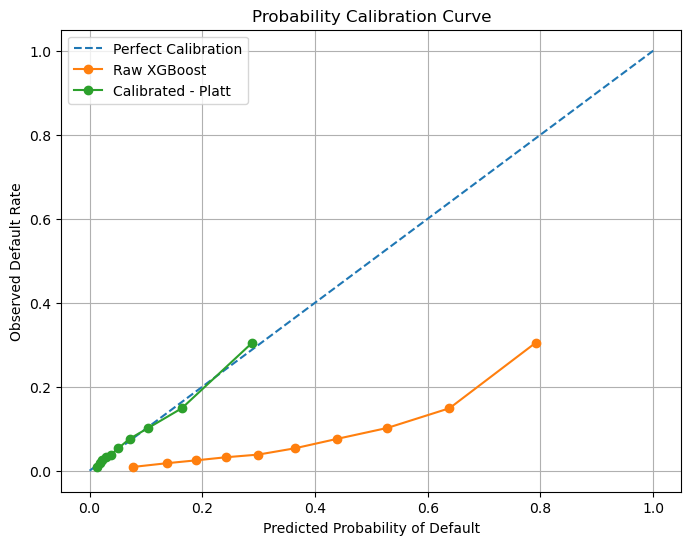

In [117]:
# ============================================================
# PROBABILITY OF DEFAULT + PROBABILITY CALIBRATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    log_loss
)

from sklearn.calibration import calibration_curve


# ============================================================
# 1. PROBABILIDADES BRUTAS DO CHAMPION MODEL
# ============================================================

# Validation
raw_val_proba = champion_model.predict_proba(
    X_val_75_processed
)[:, 1]

# Test
raw_test_proba = champion_model.predict_proba(
    X_test_75_processed
)[:, 1]


# ============================================================
# 2. DIVIDIR VALIDATION:
#    CALIBRATION FIT / CALIBRATION EVALUATION
# ============================================================

val_indices = np.arange(len(y_val))

cal_fit_idx, cal_eval_idx = train_test_split(
    val_indices,
    test_size=0.50,
    stratify=y_val,
    random_state=42
)


y_cal_fit = y_val.iloc[cal_fit_idx]
y_cal_eval = y_val.iloc[cal_eval_idx]

proba_cal_fit = raw_val_proba[cal_fit_idx]
proba_cal_eval = raw_val_proba[cal_eval_idx]


# ============================================================
# 3. PLATT SCALING / SIGMOID
# ============================================================

# Logistic Regression recebe a probabilidade bruta
# como uma única feature.

platt = LogisticRegression()

platt.fit(
    proba_cal_fit.reshape(-1, 1),
    y_cal_fit
)

platt_eval_proba = platt.predict_proba(
    proba_cal_eval.reshape(-1, 1)
)[:, 1]


# ============================================================
# 4. ISOTONIC CALIBRATION
# ============================================================

isotonic = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic.fit(
    proba_cal_fit,
    y_cal_fit
)

isotonic_eval_proba = isotonic.predict(
    proba_cal_eval
)


# ============================================================
# 5. PROBABILIDADE SEM CALIBRAÇÃO
# ============================================================

raw_eval_proba = proba_cal_eval


# ============================================================
# 6. COMPARAR MÉTODOS
# ============================================================

calibration_results = pd.DataFrame({

    "Method": [
        "Raw XGBoost",
        "Platt",
        "Isotonic"
    ],

    "ROC_AUC": [
        roc_auc_score(
            y_cal_eval,
            raw_eval_proba
        ),

        roc_auc_score(
            y_cal_eval,
            platt_eval_proba
        ),

        roc_auc_score(
            y_cal_eval,
            isotonic_eval_proba
        )
    ],

    "Brier_Score": [
        brier_score_loss(
            y_cal_eval,
            raw_eval_proba
        ),

        brier_score_loss(
            y_cal_eval,
            platt_eval_proba
        ),

        brier_score_loss(
            y_cal_eval,
            isotonic_eval_proba
        )
    ],

    "Log_Loss": [
        log_loss(
            y_cal_eval,
            raw_eval_proba
        ),

        log_loss(
            y_cal_eval,
            platt_eval_proba
        ),

        log_loss(
            y_cal_eval,
            isotonic_eval_proba
        )
    ]
})


calibration_results = calibration_results.sort_values(
    "Brier_Score",
    ascending=True
).reset_index(drop=True)


print("=" * 70)
print("CALIBRATION MODEL COMPARISON")
print("=" * 70)

display(calibration_results)


# ============================================================
# 7. ESCOLHER MELHOR MÉTODO
# ============================================================

best_method = calibration_results.iloc[0]["Method"]

print()
print(
    "Melhor método pelo Brier Score:",
    best_method
)


# ============================================================
# 8. REFIT DO CALIBRADOR COM TODA A VALIDATION
# ============================================================

if best_method == "Platt":

    final_calibrator = LogisticRegression()

    final_calibrator.fit(
        raw_val_proba.reshape(-1, 1),
        y_val
    )

    calibrated_test_proba = (
        final_calibrator.predict_proba(
            raw_test_proba.reshape(-1, 1)
        )[:, 1]
    )


elif best_method == "Isotonic":

    final_calibrator = IsotonicRegression(
        out_of_bounds="clip"
    )

    final_calibrator.fit(
        raw_val_proba,
        y_val
    )

    calibrated_test_proba = (
        final_calibrator.predict(
            raw_test_proba
        )
    )


else:

    # Caso a probabilidade bruta já seja melhor
    final_calibrator = None

    calibrated_test_proba = (
        raw_test_proba.copy()
    )


# ============================================================
# 9. RESULTADO FINAL NO TEST SET
# ============================================================

test_calibration_results = pd.DataFrame({

    "Method": [
        "Raw XGBoost",
        f"Calibrated ({best_method})"
    ],

    "ROC_AUC": [
        roc_auc_score(
            y_test,
            raw_test_proba
        ),

        roc_auc_score(
            y_test,
            calibrated_test_proba
        )
    ],

    "Brier_Score": [
        brier_score_loss(
            y_test,
            raw_test_proba
        ),

        brier_score_loss(
            y_test,
            calibrated_test_proba
        )
    ],

    "Log_Loss": [
        log_loss(
            y_test,
            raw_test_proba
        ),

        log_loss(
            y_test,
            calibrated_test_proba
        )
    ],

    "Mean_PD": [
        raw_test_proba.mean(),
        calibrated_test_proba.mean()
    ]

})


print()
print("=" * 70)
print("FINAL TEST SET CALIBRATION")
print("=" * 70)

display(
    test_calibration_results
)

print(
    "Taxa real de default no Test:",
    round(y_test.mean(), 4)
)


# ============================================================
# 10. CALIBRATION CURVE
# ============================================================

prob_true_raw, prob_pred_raw = calibration_curve(
    y_test,
    raw_test_proba,
    n_bins=10,
    strategy="quantile"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    calibrated_test_proba,
    n_bins=10,
    strategy="quantile"
)


plt.figure(figsize=(8, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    prob_pred_raw,
    prob_true_raw,
    marker="o",
    label="Raw XGBoost"
)

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label=f"Calibrated - {best_method}"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Observed Default Rate")

plt.title(
    "Probability Calibration Curve"
)

plt.legend()
plt.grid()

plt.show()

Número de features: 205


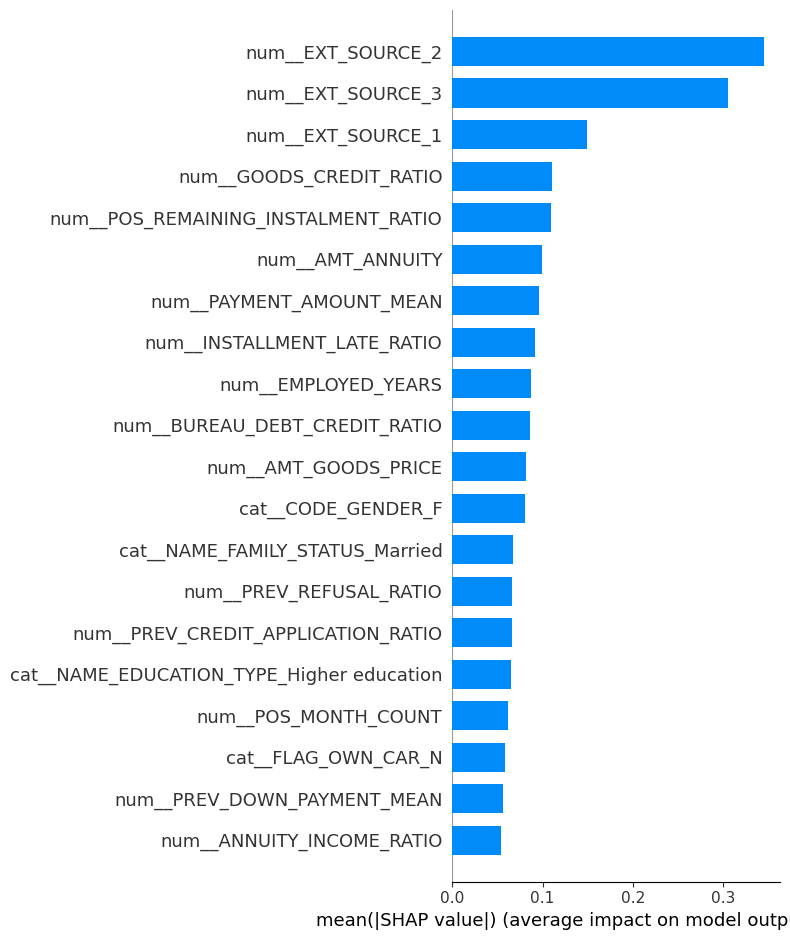

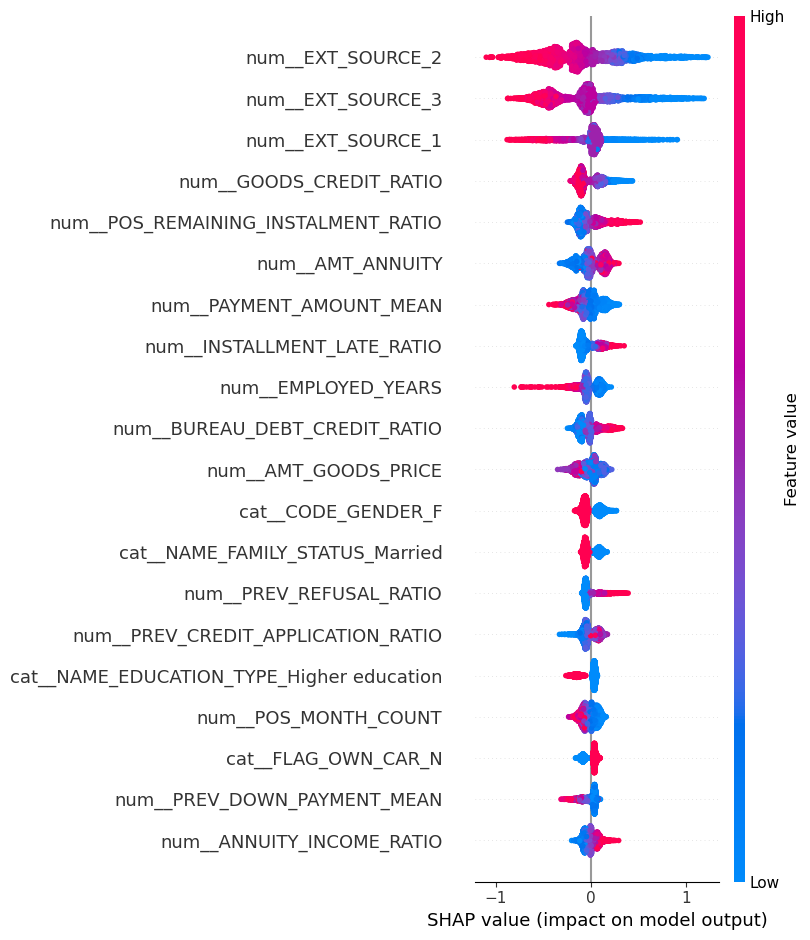


TOP 20 FEATURES POR SHAP


,Feature,Mean_ABS_SHAP
0,num__EXT_SOURCE_2,0.345304
1,num__EXT_SOURCE_3,0.305506
2,num__EXT_SOURCE_1,0.148979
3,num__GOODS_CREDIT_RATIO,0.110284
4,num__POS_REMAINING_INSTALMENT_RATIO,0.108868
5,num__AMT_ANNUITY,0.099722
6,num__PAYMENT_AMOUNT_MEAN,0.095829
7,num__INSTALLMENT_LATE_RATIO,0.091280
8,num__EMPLOYED_YEARS,0.087281
9,num__BUREAU_DEBT_CREDIT_RATIO,0.086474


In [118]:
# ============================================================
# SHAP EXPLAINABILITY - CHAMPION XGBOOST
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. FEATURE NAMES APÓS PREPROCESSAMENTO
# ============================================================

feature_names_processed = (
    preprocessor_75.get_feature_names_out()
)

print(
    "Número de features:",
    len(feature_names_processed)
)


# ============================================================
# 2. AMOSTRA DO TEST SET
# ============================================================

SHAP_SAMPLE_SIZE = 5000

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    X_test_75_processed.shape[0],
    size=min(
        SHAP_SAMPLE_SIZE,
        X_test_75_processed.shape[0]
    ),
    replace=False
)

X_shap = X_test_75_processed[
    sample_indices
]


# ============================================================
# 3. SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(
    champion_model
)

shap_values = explainer.shap_values(
    X_shap
)


# ============================================================
# 4. GLOBAL FEATURE IMPORTANCE
# ============================================================

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names_processed,
    plot_type="bar",
    max_display=20
)

plt.show()


# ============================================================
# 5. SHAP BEESWARM
# ============================================================

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names_processed,
    max_display=20
)

plt.show()


# ============================================================
# 6. TABELA DE IMPORTÂNCIA
# ============================================================

mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

shap_importance = pd.DataFrame({

    "Feature":
        feature_names_processed,

    "Mean_ABS_SHAP":
        mean_abs_shap

}).sort_values(
    "Mean_ABS_SHAP",
    ascending=False
).reset_index(drop=True)


print("\nTOP 20 FEATURES POR SHAP")

display(
    shap_importance.head(20)
)

CLIENT CREDIT RISK EXPLANATION
Raw XGBoost Probability: 93.33%
Calibrated PD:           43.69%
Actual Target:           1

TOP 15 FACTORS FOR THIS CLIENT


,Feature,Feature_Value,SHAP_Value,Risk_Impact
0,num__EXT_SOURCE_2,-2.342810,0.679232,INCREASES RISK
1,num__EXT_SOURCE_3,-2.148038,0.556502,INCREASES RISK
2,num__EXT_SOURCE_1,-2.326769,0.274813,INCREASES RISK
3,num__PREV_REFUSAL_RATIO,2.183479,0.171918,INCREASES RISK
4,num__AMT_GOODS_PRICE,-0.240307,0.163800,INCREASES RISK
5,cat__FLAG_OWN_CAR_N,0.000000,-0.098062,DECREASES RISK
6,cat__NAME_FAMILY_STATUS_Married,0.000000,0.088277,INCREASES RISK
7,num__INSTALLMENT_LATE_RATIO,1.869134,0.084106,INCREASES RISK
8,num__POS_REMAINING_INSTALMENT_RATIO,-0.728611,-0.083407,DECREASES RISK
9,num__AMT_ANNUITY,0.088492,0.081555,INCREASES RISK


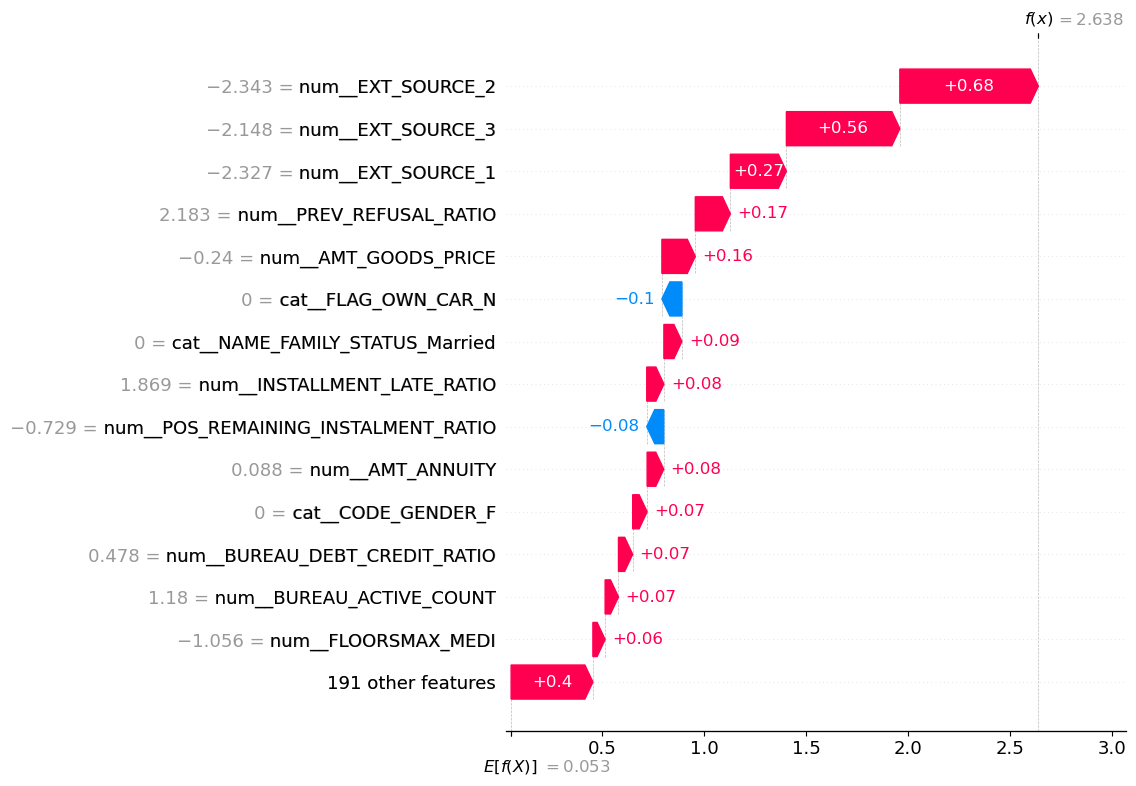

In [119]:
# ============================================================
# LOCAL SHAP EXPLANATION
# EXPLICAR UM CLIENTE INDIVIDUAL
# ============================================================

import numpy as np
import pandas as pd
import shap


# ============================================================
# 1. ESCOLHER CLIENTE
# ============================================================

# Vamos escolher um cliente de risco relativamente alto
# dentro do Test Set

risk_order = np.argsort(
    calibrated_test_proba
)[::-1]

# posição 100 para evitar escolher simplesmente
# o caso mais extremo da base

client_position = risk_order[100]


# ============================================================
# 2. INFORMAÇÕES DO CLIENTE
# ============================================================

client_pd = calibrated_test_proba[
    client_position
]

client_raw_probability = raw_test_proba[
    client_position
]

client_real_target = y_test.iloc[
    client_position
]


print("=" * 70)
print("CLIENT CREDIT RISK EXPLANATION")
print("=" * 70)

print(
    f"Raw XGBoost Probability: "
    f"{client_raw_probability:.2%}"
)

print(
    f"Calibrated PD:           "
    f"{client_pd:.2%}"
)

print(
    f"Actual Target:           "
    f"{client_real_target}"
)


# ============================================================
# 3. PEGAR FEATURES PROCESSADAS DO CLIENTE
# ============================================================

client_processed = X_test_75_processed[
    client_position
]


# ============================================================
# 4. SHAP VALUES
# ============================================================

client_shap_values = explainer.shap_values(
    client_processed.reshape(1, -1)
)[0]


# ============================================================
# 5. CRIAR TABELA DE EXPLICAÇÃO
# ============================================================

client_explanation = pd.DataFrame({

    "Feature":
        feature_names_processed,

    "Feature_Value":
        client_processed,

    "SHAP_Value":
        client_shap_values

})


# ============================================================
# 6. IMPORTÂNCIA ABSOLUTA
# ============================================================

client_explanation[
    "ABS_SHAP"
] = np.abs(
    client_explanation["SHAP_Value"]
)


client_explanation = (
    client_explanation
    .sort_values(
        "ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. DIREÇÃO DO IMPACTO
# ============================================================

client_explanation[
    "Risk_Impact"
] = np.where(

    client_explanation[
        "SHAP_Value"
    ] > 0,

    "INCREASES RISK",

    "DECREASES RISK"

)


# ============================================================
# 8. TOP 15 MOTIVOS
# ============================================================

print()
print("TOP 15 FACTORS FOR THIS CLIENT")

display(

    client_explanation[
        [
            "Feature",
            "Feature_Value",
            "SHAP_Value",
            "Risk_Impact"
        ]
    ].head(15)

)


# ============================================================
# 9. WATERFALL PLOT
# ============================================================

explanation = shap.Explanation(

    values=client_shap_values,

    base_values=explainer.expected_value,

    data=client_processed,

    feature_names=feature_names_processed

)


shap.plots.waterfall(
    explanation,
    max_display=15
)

Clientes no Test Set: 61503
Default Rate geral: 8.07%


,PD,TARGET
0,0.028810,0
1,0.031090,0
2,0.264487,0
3,0.028376,0
4,0.101628,0



DEFAULT RATE POR FAIXA DE PD


,PD_BAND,Clients,Defaults,Default_Rate,Mean_PD,Percent_Clients
0,"(-0.001, 0.02]",11917,162,1.36,1.58,19.38
1,"(0.02, 0.04]",17075,524,3.07,2.86,27.76
2,"(0.04, 0.06]",8096,406,5.01,4.90,13.16
3,"(0.06, 0.08]",5067,374,7.38,6.94,8.24
4,"(0.08, 0.1]",3493,307,8.79,8.94,5.68
5,"(0.1, 0.15]",5674,681,12.00,12.26,9.23
6,"(0.15, 0.2]",3612,568,15.73,17.39,5.87
7,"(0.2, 0.3]",4258,1008,23.67,24.34,6.92
8,"(0.3, 0.5]",2311,935,40.46,35.72,3.76
9,"(0.5, 1.0]",0,0,NaN,NaN,0.00



EXEMPLOS DE THRESHOLDS


,Approve_Threshold,Reject_Threshold,Decision,Clients,Percent_Clients,Default_Rate,Mean_PD
42,0.05,0.15,APPROVE,33669,54.74,2.67,2.63
43,0.05,0.15,REVIEW,17653,28.70,8.81,8.76
44,0.05,0.15,REJECT,10181,16.55,24.66,24.46
60,0.06,0.15,APPROVE,37088,60.30,2.94,2.89
61,0.06,0.15,REVIEW,14234,23.14,9.57,9.55
62,0.06,0.15,REJECT,10181,16.55,24.66,24.46
81,0.07,0.20,APPROVE,39848,64.79,3.22,3.14
82,0.07,0.20,REVIEW,15086,24.53,11.53,11.99
83,0.07,0.20,REJECT,6569,10.68,29.58,28.35



CREDIT DECISION ENGINE
APPROVE: PD < 5%
REVIEW:  5% <= PD < 15%
REJECT:  PD >= 15%


,Clients,Percent_Clients,Defaults,Default_Rate,Mean_PD
DECISION,,,,,
APPROVE,33669,54.74,899,2.67,2.63
REJECT,10181,16.55,2511,24.66,24.46
REVIEW,17653,28.70,1555,8.81,8.76


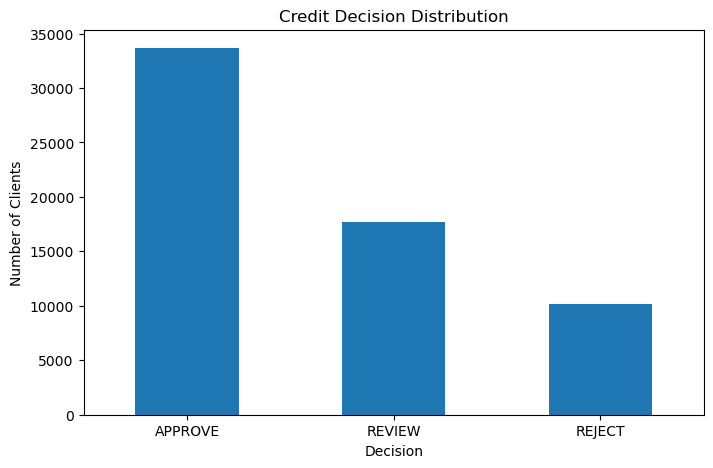


EXAMPLE CLIENT
Probability of Default: 43.69%
Credit Decision: REJECT


In [121]:
# ============================================================
# DECISION ENGINE - CREDIT RISK
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CRIAR DATAFRAME COM PD CALIBRADA E TARGET REAL
# ============================================================

decision_df = pd.DataFrame({
    "PD": calibrated_test_proba,
    "TARGET": np.asarray(y_test)
})
print("Clientes no Test Set:", len(decision_df))
print("Default Rate geral:", f"{decision_df['TARGET'].mean():.2%}")

display(decision_df.head())


# ============================================================
# 2. ANALISAR DISTRIBUIÇÃO POR FAIXA DE PD
# ============================================================

bins = [
    0.00,
    0.02,
    0.04,
    0.06,
    0.08,
    0.10,
    0.15,
    0.20,
    0.30,
    0.50,
    1.00
]

decision_df["PD_BAND"] = pd.cut(
    decision_df["PD"],
    bins=bins,
    include_lowest=True
)

pd_analysis = (
    decision_df
    .groupby("PD_BAND", observed=False)
    .agg(
        Clients=("TARGET", "size"),
        Defaults=("TARGET", "sum"),
        Default_Rate=("TARGET", "mean"),
        Mean_PD=("PD", "mean")
    )
    .reset_index()
)

pd_analysis["Percent_Clients"] = (
    pd_analysis["Clients"] /
    pd_analysis["Clients"].sum()
)

pd_analysis["Default_Rate"] *= 100
pd_analysis["Mean_PD"] *= 100
pd_analysis["Percent_Clients"] *= 100

print("\n" + "=" * 70)
print("DEFAULT RATE POR FAIXA DE PD")
print("=" * 70)

display(pd_analysis.round(2))


# ============================================================
# 3. TESTAR VÁRIAS COMBINAÇÕES DE THRESHOLDS
# ============================================================

approve_thresholds = [
    0.03,
    0.04,
    0.05,
    0.06,
    0.07,
    0.08
]

reject_thresholds = [
    0.10,
    0.12,
    0.15,
    0.20,
    0.25,
    0.30
]

results = []

for approve_threshold in approve_thresholds:

    for reject_threshold in reject_thresholds:

        if reject_threshold <= approve_threshold:
            continue

        decisions = np.where(
            decision_df["PD"] < approve_threshold,
            "APPROVE",
            np.where(
                decision_df["PD"] < reject_threshold,
                "REVIEW",
                "REJECT"
            )
        )

        temp = decision_df.copy()
        temp["DECISION"] = decisions

        for decision in ["APPROVE", "REVIEW", "REJECT"]:

            subset = temp[
                temp["DECISION"] == decision
            ]

            if len(subset) == 0:
                continue

            results.append({

                "Approve_Threshold":
                    approve_threshold,

                "Reject_Threshold":
                    reject_threshold,

                "Decision":
                    decision,

                "Clients":
                    len(subset),

                "Percent_Clients":
                    len(subset) / len(temp),

                "Default_Rate":
                    subset["TARGET"].mean(),

                "Mean_PD":
                    subset["PD"].mean()
            })


threshold_results = pd.DataFrame(results)

threshold_results["Percent_Clients"] *= 100
threshold_results["Default_Rate"] *= 100
threshold_results["Mean_PD"] *= 100


# ============================================================
# 4. MOSTRAR ALGUMAS CONFIGURAÇÕES
# ============================================================

print("\n" + "=" * 70)
print("EXEMPLOS DE THRESHOLDS")
print("=" * 70)

example_thresholds = threshold_results[
    (
        (threshold_results["Approve_Threshold"] == 0.05)
        &
        (threshold_results["Reject_Threshold"] == 0.15)
    )
    |
    (
        (threshold_results["Approve_Threshold"] == 0.06)
        &
        (threshold_results["Reject_Threshold"] == 0.15)
    )
    |
    (
        (threshold_results["Approve_Threshold"] == 0.07)
        &
        (threshold_results["Reject_Threshold"] == 0.20)
    )
]

display(
    example_thresholds.round(2)
)


# ============================================================
# 5. CRIAR FUNÇÃO DO DECISION ENGINE
# ============================================================

def credit_decision(
    pd_value,
    approve_threshold=0.05,
    reject_threshold=0.15
):

    if pd_value < approve_threshold:
        return "APPROVE"

    elif pd_value < reject_threshold:
        return "REVIEW"

    else:
        return "REJECT"


# ============================================================
# 6. APLICAR DECISION ENGINE
# ============================================================

APPROVE_THRESHOLD = 0.05
REJECT_THRESHOLD = 0.15

decision_df["DECISION"] = decision_df["PD"].apply(
    lambda x: credit_decision(
        x,
        APPROVE_THRESHOLD,
        REJECT_THRESHOLD
    )
)


# ============================================================
# 7. RESULTADO DAS DECISÕES
# ============================================================

decision_summary = (
    decision_df
    .groupby("DECISION")
    .agg(
        Clients=("TARGET", "size"),
        Defaults=("TARGET", "sum"),
        Default_Rate=("TARGET", "mean"),
        Mean_PD=("PD", "mean")
    )
)

decision_summary["Percent_Clients"] = (
    decision_summary["Clients"] /
    len(decision_df)
)

decision_summary["Default_Rate"] *= 100
decision_summary["Mean_PD"] *= 100
decision_summary["Percent_Clients"] *= 100

decision_summary = decision_summary[
    [
        "Clients",
        "Percent_Clients",
        "Defaults",
        "Default_Rate",
        "Mean_PD"
    ]
]

print("\n" + "=" * 70)
print("CREDIT DECISION ENGINE")
print("=" * 70)

print(
    f"APPROVE: PD < {APPROVE_THRESHOLD:.0%}"
)

print(
    f"REVIEW:  {APPROVE_THRESHOLD:.0%}"
    f" <= PD < {REJECT_THRESHOLD:.0%}"
)

print(
    f"REJECT:  PD >= {REJECT_THRESHOLD:.0%}"
)

display(
    decision_summary.round(2)
)


# ============================================================
# 8. GRÁFICO
# ============================================================

plot_data = (
    decision_df["DECISION"]
    .value_counts()
    .reindex(
        ["APPROVE", "REVIEW", "REJECT"]
    )
)

plt.figure(figsize=(8, 5))

plot_data.plot(
    kind="bar"
)

plt.title(
    "Credit Decision Distribution"
)

plt.xlabel(
    "Decision"
)

plt.ylabel(
    "Number of Clients"
)

plt.xticks(
    rotation=0
)

plt.show()


# ============================================================
# 9. EXEMPLO DO CLIENTE QUE ANALISAMOS COM SHAP
# ============================================================

client_pd = 0.4369

client_decision = credit_decision(
    client_pd,
    APPROVE_THRESHOLD,
    REJECT_THRESHOLD
)

print("\n" + "=" * 70)
print("EXAMPLE CLIENT")
print("=" * 70)

print(
    f"Probability of Default: {client_pd:.2%}"
)

print(
    f"Credit Decision: {client_decision}"
)

In [122]:
# ============================================================
# EXPECTED LOSS + ECONOMIC DECISION ENGINE
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. HIPÓTESES
# ============================================================

LGD = 0.60

# Vamos usar o valor do crédito como aproximação de EAD
ead_test = X_test_75["AMT_CREDIT"].to_numpy()


# ============================================================
# 2. EXPECTED LOSS
# ============================================================

expected_loss = (
    calibrated_test_proba
    * LGD
    * ead_test
)


# ============================================================
# 3. DATAFRAME ECONÔMICO
# ============================================================

economic_df = pd.DataFrame({

    "PD": calibrated_test_proba,

    "EAD": ead_test,

    "LGD": LGD,

    "Expected_Loss": expected_loss,

    "TARGET": np.asarray(y_test)

})


# ============================================================
# 4. EXPECTED LOSS COMO % DA EXPOSIÇÃO
# ============================================================

economic_df["EL_RATE"] = (
    economic_df["Expected_Loss"]
    / economic_df["EAD"]
)


# ============================================================
# 5. EXEMPLOS
# ============================================================

display(
    economic_df.head(10)
)


# ============================================================
# 6. RESUMO
# ============================================================

print("=" * 70)
print("EXPECTED LOSS SUMMARY")
print("=" * 70)

print(
    "Expected Loss total:",
    round(economic_df["Expected_Loss"].sum(), 2)
)

print(
    "Expected Loss médio por cliente:",
    round(economic_df["Expected_Loss"].mean(), 2)
)

print(
    "EAD médio:",
    round(economic_df["EAD"].mean(), 2)
)

print(
    "EL Rate médio:",
    f"{economic_df['EL_RATE'].mean():.2%}"
)


# ============================================================
# 7. JUNTAR COM DECISION ENGINE ATUAL
# ============================================================

economic_df["DECISION_PD"] = decision_df[
    "DECISION"
].values


decision_economic_summary = (
    economic_df
    .groupby("DECISION_PD")
    .agg(

        Clients=("TARGET", "size"),

        Mean_PD=("PD", "mean"),

        Default_Rate=("TARGET", "mean"),

        Mean_EAD=("EAD", "mean"),

        Mean_EL=("Expected_Loss", "mean"),

        Total_EL=("Expected_Loss", "sum"),

        Mean_EL_Rate=("EL_RATE", "mean")
    )
)


# ============================================================
# 8. FORMATAR
# ============================================================

decision_economic_summary["Mean_PD"] *= 100
decision_economic_summary["Default_Rate"] *= 100
decision_economic_summary["Mean_EL_Rate"] *= 100


print()
print("=" * 70)
print("ECONOMIC RISK BY DECISION")
print("=" * 70)

display(
    decision_economic_summary.round(2)
)


# ============================================================
# 9. EXEMPLO DE UM CLIENTE
# ============================================================

client_example = economic_df.iloc[
    client_position
]

print()
print("=" * 70)
print("CLIENT ECONOMIC RISK")
print("=" * 70)

print(
    f"PD: "
    f"{client_example['PD']:.2%}"
)

print(
    f"EAD: "
    f"{client_example['EAD']:,.2f}"
)

print(
    f"LGD: "
    f"{client_example['LGD']:.0%}"
)

print(
    f"Expected Loss: "
    f"{client_example['Expected_Loss']:,.2f}"
)

print(
    f"EL Rate: "
    f"{client_example['EL_RATE']:.2%}"
)

print(
    f"Decision: "
    f"{client_example['DECISION_PD']}"
)

,PD,EAD,LGD,Expected_Loss,TARGET,EL_RATE
0,0.028810,770292.0,0.6,13315.200276,0,0.017286
1,0.031090,364896.0,0.6,6806.759400,0,0.018654
2,0.264487,284400.0,0.6,45131.980829,0,0.158692
3,0.028376,976711.5,0.6,16629.164673,0,0.017026
4,0.101628,323194.5,0.6,19707.292803,0,0.060977
5,0.138672,318528.0,0.6,26502.546272,0,0.083203
6,0.012822,1431000.0,0.6,11008.813289,0,0.007693
7,0.013179,382500.0,0.6,3024.535153,0,0.007907
8,0.224227,170640.0,0.6,22957.283588,0,0.134536
9,0.096111,225000.0,0.6,12974.935815,1,0.057666


EXPECTED LOSS SUMMARY
Expected Loss total: 1641734378.28
Expected Loss médio por cliente: 26693.57
EAD médio: 597777.02
EL Rate médio: 4.80%

ECONOMIC RISK BY DECISION


,Clients,Mean_PD,Default_Rate,Mean_EAD,Mean_EL,Total_EL,Mean_EL_Rate
DECISION_PD,,,,,,,
APPROVE,33669,2.63,2.67,627687.20,9895.84,3.331831e+08,1.58
REJECT,10181,24.46,24.66,523700.54,75920.24,7.729439e+08,14.68
REVIEW,17653,8.76,8.81,583452.37,30340.87,5.356073e+08,5.26



CLIENT ECONOMIC RISK
PD: 43.69%
EAD: 521,280.00
LGD: 60%
Expected Loss: 136,656.01
EL Rate: 26.22%
Decision: REJECT


In [124]:
# ============================================================
# RISK-ADJUSTED PROFITABILITY - CORRECTED VERSION
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. DATASET
# ============================================================

economic_profit_df = pd.DataFrame({

    "PD": calibrated_test_proba,

    "EAD": X_test_75["AMT_CREDIT"].to_numpy(),

    "TARGET": np.asarray(y_test)

})


# ============================================================
# 2. ECONOMIC ASSUMPTIONS
# ============================================================

# IMPORTANTE:
# Estes valores são hipóteses para simulação econômica.
# A Home Credit não fornece todos esses parâmetros diretamente.

LGD = 0.60

REVENUE_RATE = 0.20

FUNDING_COST_RATE = 0.08

OPERATIONAL_COST_RATE = 0.02


print("=" * 70)
print("ECONOMIC ASSUMPTIONS")
print("=" * 70)

print(f"Revenue Rate:          {REVENUE_RATE:.2%}")
print(f"Funding Cost Rate:     {FUNDING_COST_RATE:.2%}")
print(f"Operational Cost Rate: {OPERATIONAL_COST_RATE:.2%}")
print(f"LGD:                   {LGD:.2%}")


# ============================================================
# 3. EXPECTED REVENUE
# ============================================================

economic_profit_df["EXPECTED_REVENUE"] = (

    economic_profit_df["EAD"]

    * REVENUE_RATE

    * (1 - economic_profit_df["PD"])

)


# ============================================================
# 4. EXPECTED LOSS
# ============================================================

economic_profit_df["EXPECTED_LOSS"] = (

    economic_profit_df["PD"]

    * economic_profit_df["EAD"]

    * LGD

)


# ============================================================
# 5. FUNDING COST
# ============================================================

economic_profit_df["FUNDING_COST"] = (

    economic_profit_df["EAD"]

    * FUNDING_COST_RATE

)


# ============================================================
# 6. OPERATIONAL COST
# ============================================================

economic_profit_df["OPERATIONAL_COST"] = (

    economic_profit_df["EAD"]

    * OPERATIONAL_COST_RATE

)


# ============================================================
# 7. EXPECTED PROFIT
# ============================================================

economic_profit_df["EXPECTED_PROFIT"] = (

    economic_profit_df["EXPECTED_REVENUE"]

    - economic_profit_df["EXPECTED_LOSS"]

    - economic_profit_df["FUNDING_COST"]

    - economic_profit_df["OPERATIONAL_COST"]

)


# ============================================================
# 8. PROFITABILITY RATE
# ============================================================

economic_profit_df["EXPECTED_PROFIT_MARGIN"] = (

    economic_profit_df["EXPECTED_PROFIT"]

    / economic_profit_df["EAD"]

)


# ============================================================
# 9. ECONOMIC DECISION ENGINE
# ============================================================

def economic_decision(row):

    # Negative expected profitability
    if row["EXPECTED_PROFIT"] <= 0:

        return "REJECT"

    # Positive profitability + low credit risk
    elif row["PD"] < 0.05:

        return "APPROVE"

    # Positive profitability but intermediate risk
    else:

        return "REVIEW"


economic_profit_df["ECONOMIC_DECISION"] = (

    economic_profit_df.apply(
        economic_decision,
        axis=1
    )

)


# ============================================================
# 10. SUMMARY BY DECISION
# ============================================================

economic_summary = (

    economic_profit_df

    .groupby("ECONOMIC_DECISION")

    .agg(

        Clients=("TARGET", "size"),

        Mean_PD=("PD", "mean"),

        Default_Rate=("TARGET", "mean"),

        Mean_EAD=("EAD", "mean"),

        Mean_Revenue=("EXPECTED_REVENUE", "mean"),

        Mean_Expected_Loss=("EXPECTED_LOSS", "mean"),

        Mean_Funding_Cost=("FUNDING_COST", "mean"),

        Mean_Operational_Cost=("OPERATIONAL_COST", "mean"),

        Mean_Expected_Profit=("EXPECTED_PROFIT", "mean"),

        Mean_Profit_Margin=("EXPECTED_PROFIT_MARGIN", "mean")

    )

)


# Transform percentages
economic_summary["Mean_PD"] *= 100
economic_summary["Default_Rate"] *= 100
economic_summary["Mean_Profit_Margin"] *= 100


print()
print("=" * 90)
print("RISK-ADJUSTED PROFITABILITY")
print("=" * 90)

display(
    economic_summary.round(2)
)


# ============================================================
# 11. PORTFOLIO SUMMARY
# ============================================================

total_ead = economic_profit_df["EAD"].sum()

total_revenue = economic_profit_df[
    "EXPECTED_REVENUE"
].sum()

total_el = economic_profit_df[
    "EXPECTED_LOSS"
].sum()

total_funding = economic_profit_df[
    "FUNDING_COST"
].sum()

total_operational = economic_profit_df[
    "OPERATIONAL_COST"
].sum()

total_profit = economic_profit_df[
    "EXPECTED_PROFIT"
].sum()


print()
print("=" * 70)
print("PORTFOLIO ECONOMIC SUMMARY")
print("=" * 70)

print(f"Total EAD:              {total_ead:,.2f}")

print(f"Expected Revenue:       {total_revenue:,.2f}")

print(f"Expected Loss:          {total_el:,.2f}")

print(f"Funding Cost:           {total_funding:,.2f}")

print(f"Operational Cost:       {total_operational:,.2f}")

print("-" * 70)

print(f"Expected Profit:        {total_profit:,.2f}")

print(
    f"Portfolio Profit Margin: "
    f"{total_profit / total_ead:.2%}"
)


# ============================================================
# 12. DECISION DISTRIBUTION
# ============================================================

decision_distribution = (

    economic_profit_df[
        "ECONOMIC_DECISION"
    ]

    .value_counts()

    .to_frame("Clients")

)


decision_distribution["Percent"] = (

    decision_distribution["Clients"]

    / len(economic_profit_df)

    * 100

)


print()
print("=" * 70)
print("ECONOMIC DECISION DISTRIBUTION")
print("=" * 70)

display(
    decision_distribution.round(2)
)


# ============================================================
# 13. CLIENT EXAMPLE
# ============================================================

client_profit = economic_profit_df.iloc[
    client_position
]


print()
print("=" * 70)
print("CLIENT PROFITABILITY EXAMPLE")
print("=" * 70)

print(
    f"PD:                     "
    f"{client_profit['PD']:.2%}"
)

print(
    f"EAD:                    "
    f"{client_profit['EAD']:,.2f}"
)

print(
    f"Expected Revenue:       "
    f"{client_profit['EXPECTED_REVENUE']:,.2f}"
)

print(
    f"Expected Loss:          "
    f"{client_profit['EXPECTED_LOSS']:,.2f}"
)

print(
    f"Funding Cost:           "
    f"{client_profit['FUNDING_COST']:,.2f}"
)

print(
    f"Operational Cost:       "
    f"{client_profit['OPERATIONAL_COST']:,.2f}"
)

print("-" * 70)

print(
    f"Expected Profit:        "
    f"{client_profit['EXPECTED_PROFIT']:,.2f}"
)

print(
    f"Expected Profit Margin: "
    f"{client_profit['EXPECTED_PROFIT_MARGIN']:.2%}"
)

print(
    f"Economic Decision:      "
    f"{client_profit['ECONOMIC_DECISION']}"
)

ECONOMIC ASSUMPTIONS
Revenue Rate:          20.00%
Funding Cost Rate:     8.00%
Operational Cost Rate: 2.00%
LGD:                   60.00%

RISK-ADJUSTED PROFITABILITY


,Clients,Mean_PD,Default_Rate,Mean_EAD,Mean_Revenue,Mean_Expected_Loss,Mean_Funding_Cost,Mean_Operational_Cost,Mean_Expected_Profit,Mean_Profit_Margin
ECONOMIC_DECISION,,,,,,,,,,
APPROVE,33669,2.63,2.67,627687.20,122238.83,9895.84,50214.98,12553.74,49574.26,7.90
REJECT,12595,22.40,22.49,529934.22,82611.32,70126.56,42394.74,10598.68,-40508.66,-7.92
REVIEW,15239,7.98,8.09,587765.49,108250.06,27909.13,47021.24,11755.31,21564.38,3.61



PORTFOLIO ECONOMIC SUMMARY
Total EAD:              36,765,080,145.00
Expected Revenue:       6,805,771,236.24
Expected Loss:          1,641,734,378.28
Funding Cost:           2,941,206,411.60
Operational Cost:       735,301,602.90
----------------------------------------------------------------------
Expected Profit:        1,487,528,843.46
Portfolio Profit Margin: 4.05%

ECONOMIC DECISION DISTRIBUTION


,Clients,Percent
ECONOMIC_DECISION,,
APPROVE,33669,54.74
REVIEW,15239,24.78
REJECT,12595,20.48



CLIENT PROFITABILITY EXAMPLE
PD:                     43.69%
EAD:                    521,280.00
Expected Revenue:       58,704.00
Expected Loss:          136,656.01
Funding Cost:           41,702.40
Operational Cost:       10,425.60
----------------------------------------------------------------------
Expected Profit:        -130,080.01
Expected Profit Margin: -24.95%
Economic Decision:      REJECT


In [125]:
# ============================================================
# SAVE PRODUCTION ARTIFACTS
# ============================================================

from pathlib import Path
import joblib
import json


# ============================================================
# 1. CRIAR PASTA DE ARTEFATOS
# ============================================================

artifacts_path = Path("../artifacts")
artifacts_path.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. SALVAR CHAMPION MODEL
# ============================================================

joblib.dump(
    champion_model,
    artifacts_path / "xgboost_champion.joblib"
)


# ============================================================
# 3. SALVAR PREPROCESSOR
# ============================================================

joblib.dump(
    preprocessor_75,
    artifacts_path / "preprocessor.joblib"
)


# ============================================================
# 4. SALVAR CALIBRADOR
# ============================================================

joblib.dump(
    final_calibrator,
    artifacts_path / "platt_calibrator.joblib"
)


# ============================================================
# 5. SALVAR TOP 75 FEATURES
# ============================================================

joblib.dump(
    top_75_features,
    artifacts_path / "top_75_features.joblib"
)


# ============================================================
# 6. SALVAR CONFIGURAÇÕES DO DECISION ENGINE
# ============================================================

config = {

    "approve_threshold": 0.05,

    "reject_threshold": 0.15,

    "lgd": 0.60,

    "revenue_rate": 0.20,

    "funding_cost_rate": 0.08,

    "operational_cost_rate": 0.02,

    "model_test_roc_auc": float(auc_test),

    "model_validation_roc_auc": float(auc_val),

    "calibration_method": "Platt"
}


with open(
    artifacts_path / "model_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )


# ============================================================
# 7. VERIFICAR ARQUIVOS
# ============================================================

print("Artefatos salvos:")

for file in artifacts_path.iterdir():

    print(
        "-",
        file.name
    )

Artefatos salvos:
- model_config.json
- platt_calibrator.joblib
- preprocessor.joblib
- top_75_features.joblib
- xgboost_champion.joblib


In [126]:
from src.predict import predict_credit_risk, model_info

In [127]:
model_info()

{'model': 'XGBoost',
 'calibration': 'Platt',
 'test_roc_auc': 0.7823536697880601,
 'validation_roc_auc': 0.7801511441473122,
 'number_of_features': 75,
 'status': 'ready'}

In [128]:
client = X_test_75.iloc[0].to_dict()

result = predict_credit_risk(client)

result

{'probability_of_default': 0.02881,
 'risk_level': 'LOW',
 'ead': 770292.0,
 'expected_revenue': np.float64(149620.0),
 'expected_loss': np.float64(13315.2),
 'funding_cost': 61623.36,
 'operational_cost': 15405.84,
 'expected_profit': np.float64(59275.6),
 'expected_profit_margin': np.float64(0.076952),
 'decision': 'APPROVE'}

In [129]:
print("PD notebook:", calibrated_test_proba[0])
print("PD predict.py:", result["probability_of_default"])

PD notebook: 0.02880985452316617
PD predict.py: 0.02881


In [130]:
import json

# Mesmo cliente que usamos para testar o predict.py
client = X_test_75.iloc[0].to_dict()

# Converter tipos numpy para tipos Python
client_clean = {}

for key, value in client.items():
    if hasattr(value, "item"):
        value = value.item()

    # NaN não é JSON válido
    if pd.isna(value):
        value = None

    client_clean[key] = value


# Formato esperado pela nossa API
api_request = {
    "features": client_clean
}

print(json.dumps(api_request, indent=2))

{
  "features": {
    "ORGANIZATION_TYPE": "Transport: type 4",
    "OCCUPATION_TYPE": "Laborers",
    "NAME_EDUCATION_TYPE": "Higher education",
    "EXT_SOURCE_3": 0.4276573700350293,
    "CODE_GENDER": "M",
    "EXT_SOURCE_2": 0.5943267272127163,
    "NAME_FAMILY_STATUS": "Married",
    "WEEKDAY_APPR_PROCESS_START": "MONDAY",
    "FLAG_OWN_CAR": "Y",
    "WALLSMATERIAL_MODE": null,
    "NAME_HOUSING_TYPE": "House / apartment",
    "NAME_TYPE_SUITE": "Family",
    "NAME_INCOME_TYPE": "Working",
    "FONDKAPREMONT_MODE": null,
    "INSTALLMENT_LATE_RATIO": 0.0,
    "EXT_SOURCE_1": null,
    "EMPLOYED_YEARS": 0.2874743326488706,
    "NAME_CONTRACT_TYPE": "Cash loans",
    "PREV_REFUSAL_RATIO": 0.0,
    "GOODS_CREDIT_RATIO": 0.893816890218255,
    "EMERGENCYSTATE_MODE": null,
    "CC_UTILIZATION_MEAN": 0.0,
    "POS_CONTRACT_COUNT": 1.0,
    "FLAG_DOCUMENT_3": 0,
    "CC_DRAWINGS_MEAN": 0.0,
    "AGE_YEARS": 36.97741273100616,
    "HOUSETYPE_MODE": null,
    "PAYMENT_INSTALLMENT_RATIO":